In [9]:
# Importance analysis for RQ3 - inspection of context responses
import pandas as pd
from pathlib import Path
df_imp_cxt = pd.read_csv('../2_context/contextResponses/contextImportanceResponses.csv')

df_imp_cxt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6600 entries, 0 to 6599
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   row_id         6600 non-null   object
 1   base_model     6600 non-null   object
 2   variant_id     6600 non-null   object
 3   model          6600 non-null   object
 4   dc_solution    6600 non-null   object
 5   rating         6600 non-null   int64 
 6   label          6600 non-null   object
 7   iteration      6600 non-null   int64 
 8   timestamp      6600 non-null   object
 9   justification  6592 non-null   object
dtypes: int64(2), object(8)
memory usage: 515.8+ KB


In [10]:
# Importance analysis for RQ3 - inspection of anchor responses
import pandas as pd
from pathlib import Path
df_imp_anchor = pd.read_csv('../3_anchor/anchorResponses/anchorImportanceResponses.csv')

df_imp_anchor.info()

# unique iteration per anchor type
df_imp_anchor.groupby('anchor_type')['iteration'].nunique()

print("Unique iteration per anchor type:")
for anchor_type, group in df_imp_anchor.groupby('anchor_type'):
    unique_iterations = group['iteration'].nunique()
    print(f"{anchor_type}: {unique_iterations} unique iterations")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5280 entries, 0 to 5279
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   row_id         5280 non-null   object
 1   base_model     5280 non-null   object
 2   variant_id     5280 non-null   object
 3   model          5280 non-null   object
 4   dc_solution    5280 non-null   object
 5   rating         5280 non-null   int64 
 6   label          5280 non-null   object
 7   iteration      5280 non-null   int64 
 8   timestamp      5280 non-null   object
 9   justification  5259 non-null   object
 10  condition      5280 non-null   object
 11  anchor_type    5280 non-null   object
 12  anchor_level   2640 non-null   object
dtypes: int64(2), object(11)
memory usage: 536.4+ KB
Unique iteration per anchor type:
ANCHOR_EXAMPLE: 10 unique iterations
ANCHOR_NUM_HIGH: 10 unique iterations
ANCHOR_NUM_LOW: 10 unique iterations
ANCHOR_WORD: 10 unique iterations


In [11]:
# cell3: merging anchor and context data of importance responses
import pandas as pd
# create output directory
output_dir = Path('imp-ctx-anchor-working')
output_dir.mkdir(parents=True, exist_ok=True)

# load data
df_imp_cxt = pd.read_csv('../2_context/contextResponses/contextImportanceResponses.csv')
df_imp_anchor = pd.read_csv('../3_anchor/anchorResponses/anchorImportanceResponses.csv')

# define source and condition
df_imp_cxt['condition'] = 'context'
df_imp_anchor['condition'] = 'anchor'

# exact columns to keep
columns_to_keep = ['row_id', 'variant_id', 'base_model', 'model', 'dc_solution', 'rating', 'label', 'condition', 'anchor_type', 'anchor_level', 'iteration']

# add any missing columns
for column in columns_to_keep:
    if column not in df_imp_cxt.columns: df_imp_cxt[column] = pd.NA
    if column not in df_imp_anchor.columns: df_imp_anchor[column] = pd.NA

# combine the dataframes
df_combined = pd.concat([df_imp_cxt[columns_to_keep], df_imp_anchor[columns_to_keep]], ignore_index=True)

# save combined dataframe
df_combined.to_csv(output_dir / 'imp-ctx-anchor-responses.csv', index=False)

df_combined.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11880 entries, 0 to 11879
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   row_id        11880 non-null  object
 1   variant_id    11880 non-null  object
 2   base_model    11880 non-null  object
 3   model         11880 non-null  object
 4   dc_solution   11880 non-null  object
 5   rating        11880 non-null  int64 
 6   label         11880 non-null  object
 7   condition     11880 non-null  object
 8   anchor_type   5280 non-null   object
 9   anchor_level  2640 non-null   object
 10  iteration     11880 non-null  int64 
dtypes: int64(2), object(9)
memory usage: 1021.1+ KB


In [5]:
# setup code for all results presentations
from pathlib import Path
import textwrap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D
from IPython.display import display

# Paths relative to rq3-rerun/rq3-imp-analysis.ipynb
working_dir = Path("imp-ctx-anchor-working")

model_labels = {
    "gemma3": "Gemma3:12B",
    "llama": "LLaMa-Pro",
    "mistral": "Mistral",
    "phi4": "Phi-4",
}

model_order = [
    "phi4",
    "gemma3",
    "mistral",
    "llama",
]

anchor_labels = {
    "ANCHOR_EXAMPLE": "Example Anchor",
    "ANCHOR_WORD": "Word Anchor",
    "ANCHOR_NUM_HIGH": "High-numeric Anchor",
    "ANCHOR_NUM_LOW": "Low-numeric Anchor",
}

anchor_short_labels = {
    "ANCHOR_EXAMPLE": "Example",
    "ANCHOR_WORD": "Word",
    "ANCHOR_NUM_HIGH": "High numeric",
    "ANCHOR_NUM_LOW": "Low numeric",
}

anchor_order = [
    "ANCHOR_EXAMPLE",
    "ANCHOR_WORD",
    "ANCHOR_NUM_HIGH",
    "ANCHOR_NUM_LOW",
]

conclusion_labels = {
    "higher under Anchor": "Higher under Anchor",
    "lower under Anchor": "Lower under Anchor",
    "uncertain": "Uncertain",
}


def require_columns(data, required_columns, source_name):
    missing = set(required_columns).difference(data.columns)

    if missing:
        raise ValueError(
            f"{source_name} is missing columns: "
            + ", ".join(sorted(missing))
        )


def format_number(value):
    value = float(value)

    if value != 0 and (
        abs(value) < 0.001 or abs(value) >= 1000
    ):
        mantissa, exponent = f"{value:.2e}".split("e")
        return (
            rf"${mantissa}\times 10^{{{int(exponent)}}}$"
        )

    return f"{value:.3f}"


def format_probability(value):
    value = float(value)

    if value >= 0.9995:
        return r"$>0.999$"

    if value <= 0.0005:
        return r"$<0.001$"

    return f"{value:.3f}"


def add_table_note(latex, note_text, longtable=False):
    note = (
        "\n"
        "\\noindent\\begin{minipage}{\\linewidth}\n"
        "\\footnotesize\\textit{Note.} "
        + note_text
        + "\n\\end{minipage}\n"
    )

    if longtable:
        return latex + note

    return latex.replace(
        "\\end{tabular}",
        "\\end{tabular}\n" + note,
        1,
    )


print("RQ3 importance notebook setup complete.")

RQ3 importance notebook setup complete.


In [7]:
# primary-prior effect tables for the online appendix per anchor type: it is the extension or expanded view of the four forest plots plotted per anchor type that have been used in the paper
effects_input_path = (
    working_dir
    / "bayesian-results"
    / "prior-sensitivity"
    / "rq3_importance_prior_sensitivity_effects.csv"
)

if not effects_input_path.exists():
    raise FileNotFoundError(
        "RQ3 importance sensitivity effects were not found:\n"
        f"{effects_input_path.resolve()}"
    )

effects = pd.read_csv(effects_input_path)

require_columns(
    effects,
    {
        "prior_name",
        "base_model",
        "dc_solution",
        "anchor_type",
        "comparison",
        "OR_median",
        "OR_l95",
        "OR_u95",
        "posterior_probability_OR_gt_1",
        "conclusion",
    },
    "RQ3 importance sensitivity effects",
)

primary = effects.loc[
    effects["prior_name"].eq("primary")
].copy()

if len(primary) != 176:
    raise ValueError(
        "Expected 176 primary-prior effects, "
        f"found {len(primary)}."
    )

if primary.duplicated(
    subset=[
        "base_model",
        "dc_solution",
        "anchor_type",
    ]
).any():
    raise ValueError(
        "Duplicate model/DC-solution/anchor contrasts found."
    )

if set(primary["base_model"]) != set(model_order):
    raise ValueError(
        "The expected four base models were not found."
    )

if set(primary["anchor_type"]) != set(anchor_order):
    raise ValueError(
        "The expected four anchor types were not found."
    )

model_rank = {
    model: rank
    for rank, model in enumerate(model_order)
}

solution_order = (
    primary["dc_solution"]
    .drop_duplicates()
    .tolist()
)

solution_rank = {
    solution: rank
    for rank, solution in enumerate(solution_order)
}

primary["_model_order"] = primary[
    "base_model"
].map(model_rank)

primary["_solution_order"] = primary[
    "dc_solution"
].map(solution_rank)

primary = (
    primary
    .sort_values([
        "_model_order",
        "anchor_type",
        "_solution_order",
    ])
    .reset_index(drop=True)
)

anchor_filename_labels = {
    "ANCHOR_EXAMPLE": "anchor_example",
    "ANCHOR_WORD": "anchor_word",
    "ANCHOR_NUM_HIGH": "anchor_num_high",
    "ANCHOR_NUM_LOW": "anchor_num_low",
}

generated_tables = {}

for anchor_type in anchor_order:
    anchor_data = (
        primary.loc[
            primary["anchor_type"].eq(anchor_type)
        ]
        .sort_values([
            "_model_order",
            "_solution_order",
        ])
        .reset_index(drop=True)
    )

    if len(anchor_data) != 44:
        raise ValueError(
            f"Expected 44 effects for {anchor_type}, "
            f"found {len(anchor_data)}."
        )

    table = pd.DataFrame({
        "Model": anchor_data["base_model"].map(
            model_labels
        ),

        "DC solution": anchor_data["dc_solution"],

        "OR": anchor_data["OR_median"].map(
            format_number
        ),

        r"95\% CrI": [
            (
                f"[{format_number(lower)}, "
                f"{format_number(upper)}]"
            )
            for lower, upper in zip(
                anchor_data["OR_l95"],
                anchor_data["OR_u95"],
            )
        ],

        r"$P(\mathrm{OR}>1)$": anchor_data[
            "posterior_probability_OR_gt_1"
        ].map(format_probability),

        "Interpretation": anchor_data[
            "conclusion"
        ].map(conclusion_labels),
    })

    if table.isna().any().any():
        raise ValueError(
            f"Missing table values for {anchor_type}."
        )

    filename_label = anchor_filename_labels[
        anchor_type
    ]

    output_path = (
        working_dir
        / (
            "rq3_importance_primary_"
            f"{filename_label}_table.tex"
        )
    )

    latex = table.to_latex(
        index=False,
        escape=False,
        longtable=True,
        column_format=(
            r"p{2.2cm}"
            r"p{5.0cm}"
            r"c"
            r"c"
            r"c"
            r"p{3.2cm}"
        ),
        caption=(
            "RQ3 importance: posterior effects of the "
            f"{anchor_labels[anchor_type]} relative to Context "
            "for each base model and DC solution under the "
            "primary prior."
        ),
        label=(
            "tab:rq3_importance_"
            f"{filename_label}_appendix"
        ),
        position="tbp",
    )

    latex = add_table_note(
        latex,
        (
            "Each row is a separately estimated "
            "base-model/DC-solution contrast. "
            "OR $>1$ indicates higher odds of receiving a higher "
            "importance rating under the specified anchor relative "
            "to Context; OR $<1$ indicates lower odds. "
            "CrI denotes the 95\\% Bayesian credible interval. "
            "$P(\\mathrm{OR}>1)$ is the posterior probability "
            "that the odds ratio exceeds one. "
            "The primary effect prior was Normal$(0,1.5)$."
        ),
        longtable=True,
    )

    output_path.write_text(
        latex,
        encoding="utf-8",
    )

    generated_tables[anchor_type] = output_path

    print(
        f"\n{anchor_labels[anchor_type]} table:"
    )
    print(output_path.resolve())

    display(table.head(8))

print("\nAll four primary-effect tables generated.")


Example Anchor table:
/Users/HP/Documents/second-publication/current-analysis/re-run/rq3-rerun/imp-ctx-anchor-working/rq3_importance_primary_anchor_example_table.tex


,Model,DC solution,OR,95\% CrI,$P(\mathrm{OR}>1)$,Interpretation
0,Phi-4,DC-DC converter,1.409,"[0.123, 21.436]",0.606,Uncertain
1,Phi-4,DC connectors,0.504,"[0.214, 1.270]",0.071,Uncertain
2,Phi-4,DC measurement device,0.474,"[0.210, 1.020]",0.029,Uncertain
3,Phi-4,DC solution design tool,1.428,"[0.124, 21.813]",0.603,Uncertain
4,Phi-4,LVAC-LVDC interlink converter,0.648,"[0.268, 1.741]",0.188,Uncertain
5,Phi-4,Network design tool for DC solutions,0.261,"[0.047, 1.747]",0.078,Uncertain
6,Phi-4,Protection DC system design tool,0.587,"[0.089, 5.350]",0.304,Uncertain
7,Phi-4,Semiconductor-based circuit breaker,1.451,"[0.126, 23.529]",0.597,Uncertain



Word Anchor table:
/Users/HP/Documents/second-publication/current-analysis/re-run/rq3-rerun/imp-ctx-anchor-working/rq3_importance_primary_anchor_word_table.tex


,Model,DC solution,OR,95\% CrI,$P(\mathrm{OR}>1)$,Interpretation
0,Phi-4,DC-DC converter,1.393,"[0.128, 22.404]",0.601,Uncertain
1,Phi-4,DC connectors,7.135,"[1.515, 55.912]",0.995,Higher under Anchor
2,Phi-4,DC measurement device,8.085,"[2.843, 30.232]",$>0.999$,Higher under Anchor
3,Phi-4,DC solution design tool,1.422,"[0.132, 22.408]",0.608,Uncertain
4,Phi-4,LVAC-LVDC interlink converter,7.609,"[1.579, 66.391]",0.995,Higher under Anchor
5,Phi-4,Network design tool for DC solutions,1.919,"[0.200, 26.536]",0.694,Uncertain
6,Phi-4,Protection DC system design tool,1.903,"[0.221, 23.540]",0.707,Uncertain
7,Phi-4,Semiconductor-based circuit breaker,1.397,"[0.116, 21.165]",0.602,Uncertain



High-numeric Anchor table:
/Users/HP/Documents/second-publication/current-analysis/re-run/rq3-rerun/imp-ctx-anchor-working/rq3_importance_primary_anchor_num_high_table.tex


,Model,DC solution,OR,95\% CrI,$P(\mathrm{OR}>1)$,Interpretation
0,Phi-4,DC-DC converter,1.385,"[0.117, 23.591]",0.602,Uncertain
1,Phi-4,DC connectors,1.549,"[0.533, 5.482]",0.774,Uncertain
2,Phi-4,DC measurement device,1.586,"[0.732, 3.586]",0.871,Uncertain
3,Phi-4,DC solution design tool,1.383,"[0.116, 21.609]",0.601,Uncertain
4,Phi-4,LVAC-LVDC interlink converter,1.672,"[0.574, 6.144]",0.824,Uncertain
5,Phi-4,Network design tool for DC solutions,1.808,"[0.201, 24.025]",0.693,Uncertain
6,Phi-4,Protection DC system design tool,1.858,"[0.211, 22.999]",0.705,Uncertain
7,Phi-4,Semiconductor-based circuit breaker,1.417,"[0.120, 21.507]",0.608,Uncertain



Low-numeric Anchor table:
/Users/HP/Documents/second-publication/current-analysis/re-run/rq3-rerun/imp-ctx-anchor-working/rq3_importance_primary_anchor_num_low_table.tex


,Model,DC solution,OR,95\% CrI,$P(\mathrm{OR}>1)$,Interpretation
0,Phi-4,DC-DC converter,1.422,"[0.119, 22.599]",0.600,Uncertain
1,Phi-4,DC connectors,3.611,"[0.956, 20.708]",0.972,Uncertain
2,Phi-4,DC measurement device,0.417,"[0.184, 0.900]",0.013,Lower under Anchor
3,Phi-4,DC solution design tool,1.442,"[0.128, 22.925]",0.609,Uncertain
4,Phi-4,LVAC-LVDC interlink converter,0.552,"[0.231, 1.351]",0.097,Uncertain
5,Phi-4,Network design tool for DC solutions,0.256,"[0.047, 1.755]",0.080,Uncertain
6,Phi-4,Protection DC system design tool,0.080,"[0.019, 0.321]",$<0.001$,Lower under Anchor
7,Phi-4,Semiconductor-based circuit breaker,1.381,"[0.122, 22.684]",0.596,Uncertain



All four primary-effect tables generated.


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.



Saved Example Anchor:
/Users/HP/Documents/second-publication/current-analysis/re-run/rq3-rerun/imp-ctx-anchor-working/rq3_importance_primary_forest_anchor_example.png
/Users/HP/Documents/second-publication/current-analysis/re-run/rq3-rerun/imp-ctx-anchor-working/rq3_importance_primary_forest_anchor_example.eps


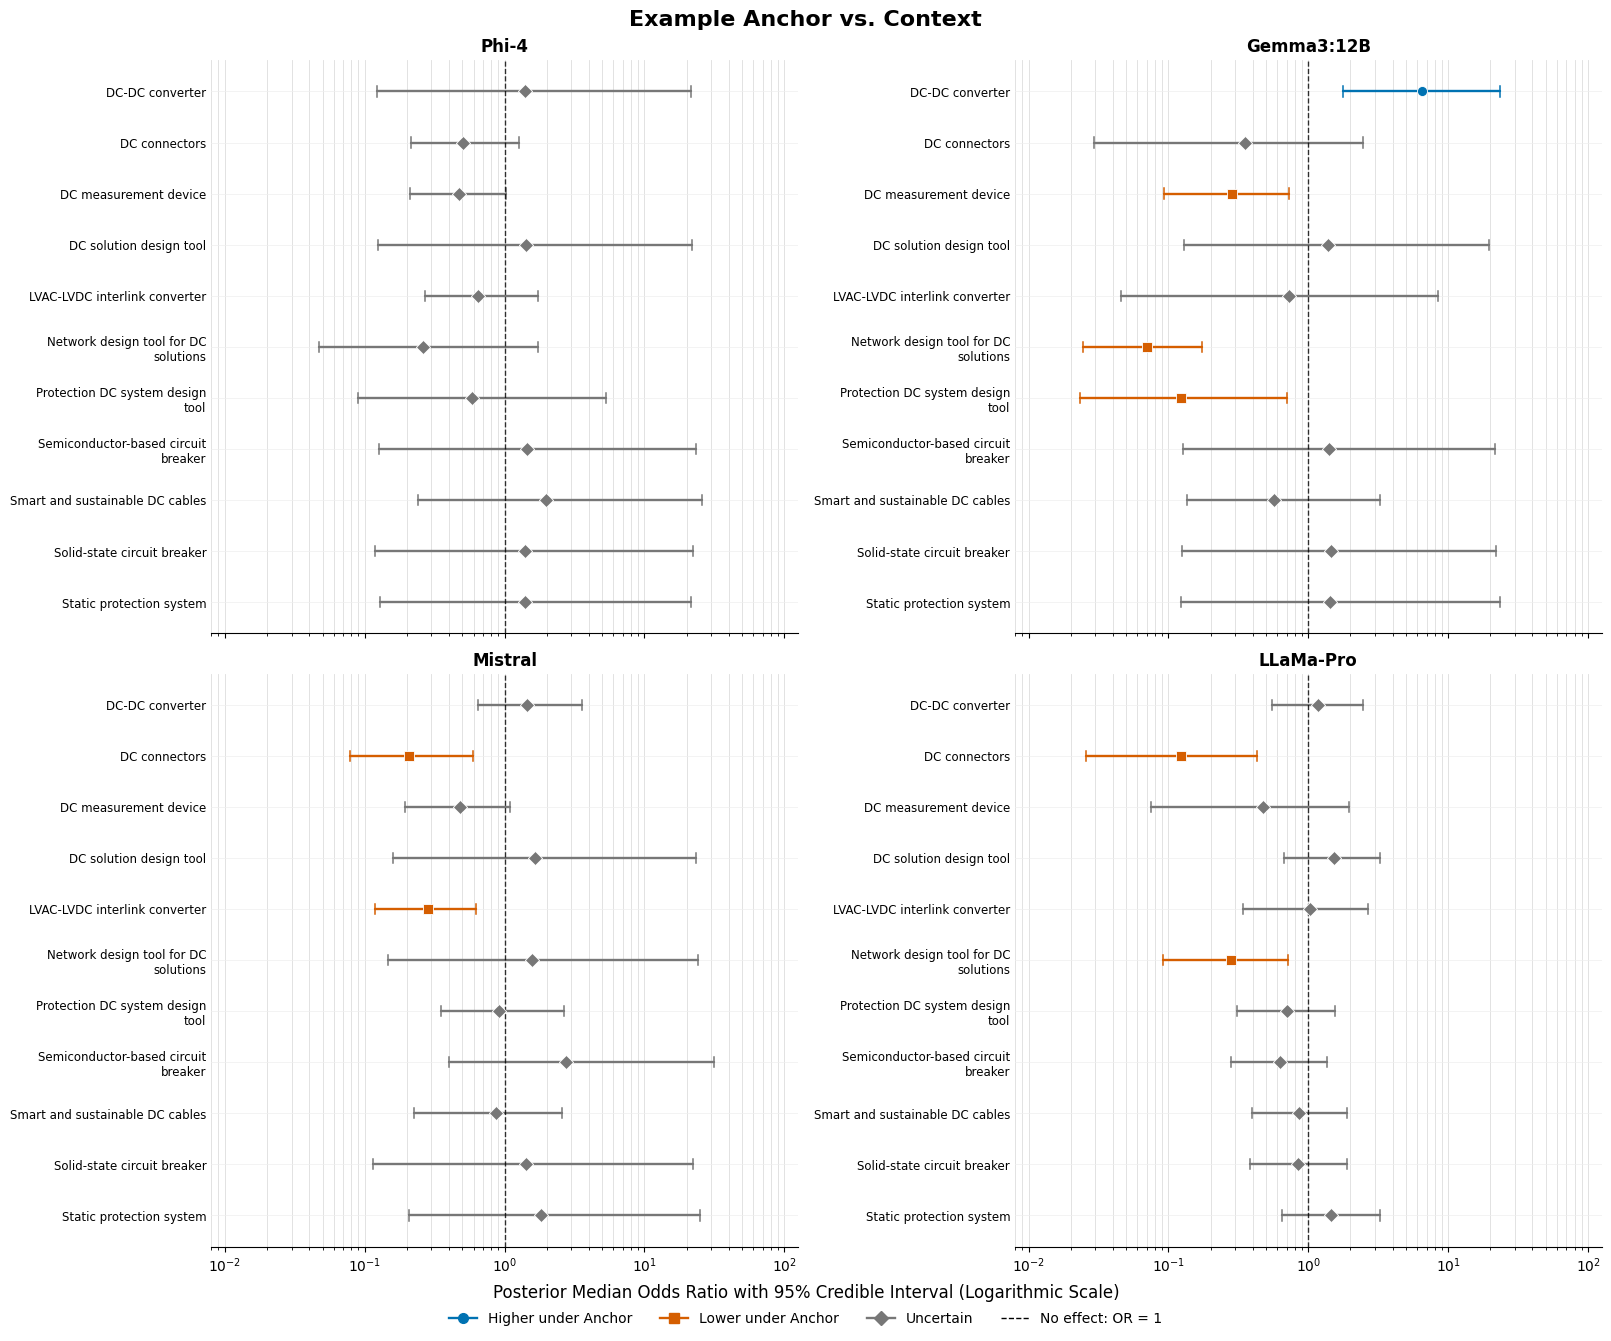

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.



Saved Word Anchor:
/Users/HP/Documents/second-publication/current-analysis/re-run/rq3-rerun/imp-ctx-anchor-working/rq3_importance_primary_forest_anchor_word.png
/Users/HP/Documents/second-publication/current-analysis/re-run/rq3-rerun/imp-ctx-anchor-working/rq3_importance_primary_forest_anchor_word.eps


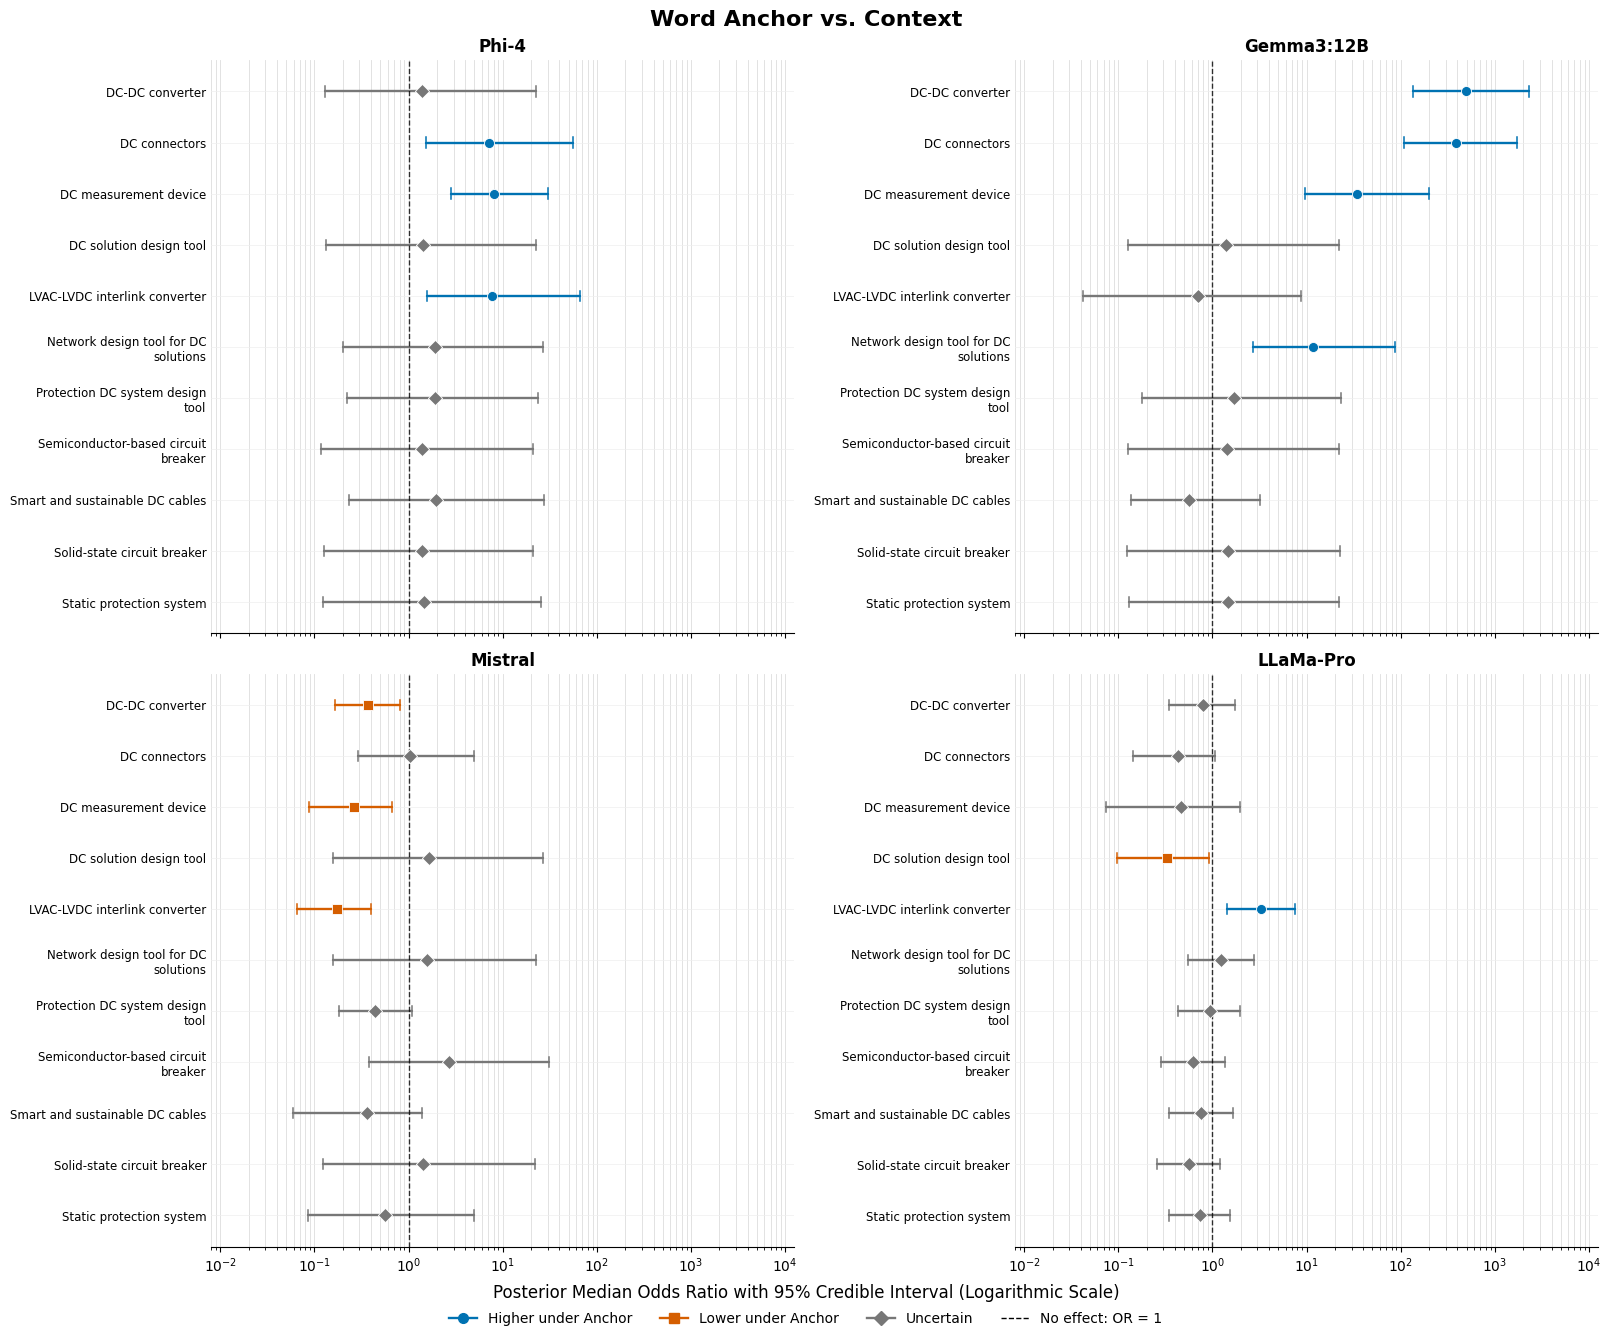

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.



Saved High-numeric Anchor:
/Users/HP/Documents/second-publication/current-analysis/re-run/rq3-rerun/imp-ctx-anchor-working/rq3_importance_primary_forest_anchor_num_high.png
/Users/HP/Documents/second-publication/current-analysis/re-run/rq3-rerun/imp-ctx-anchor-working/rq3_importance_primary_forest_anchor_num_high.eps


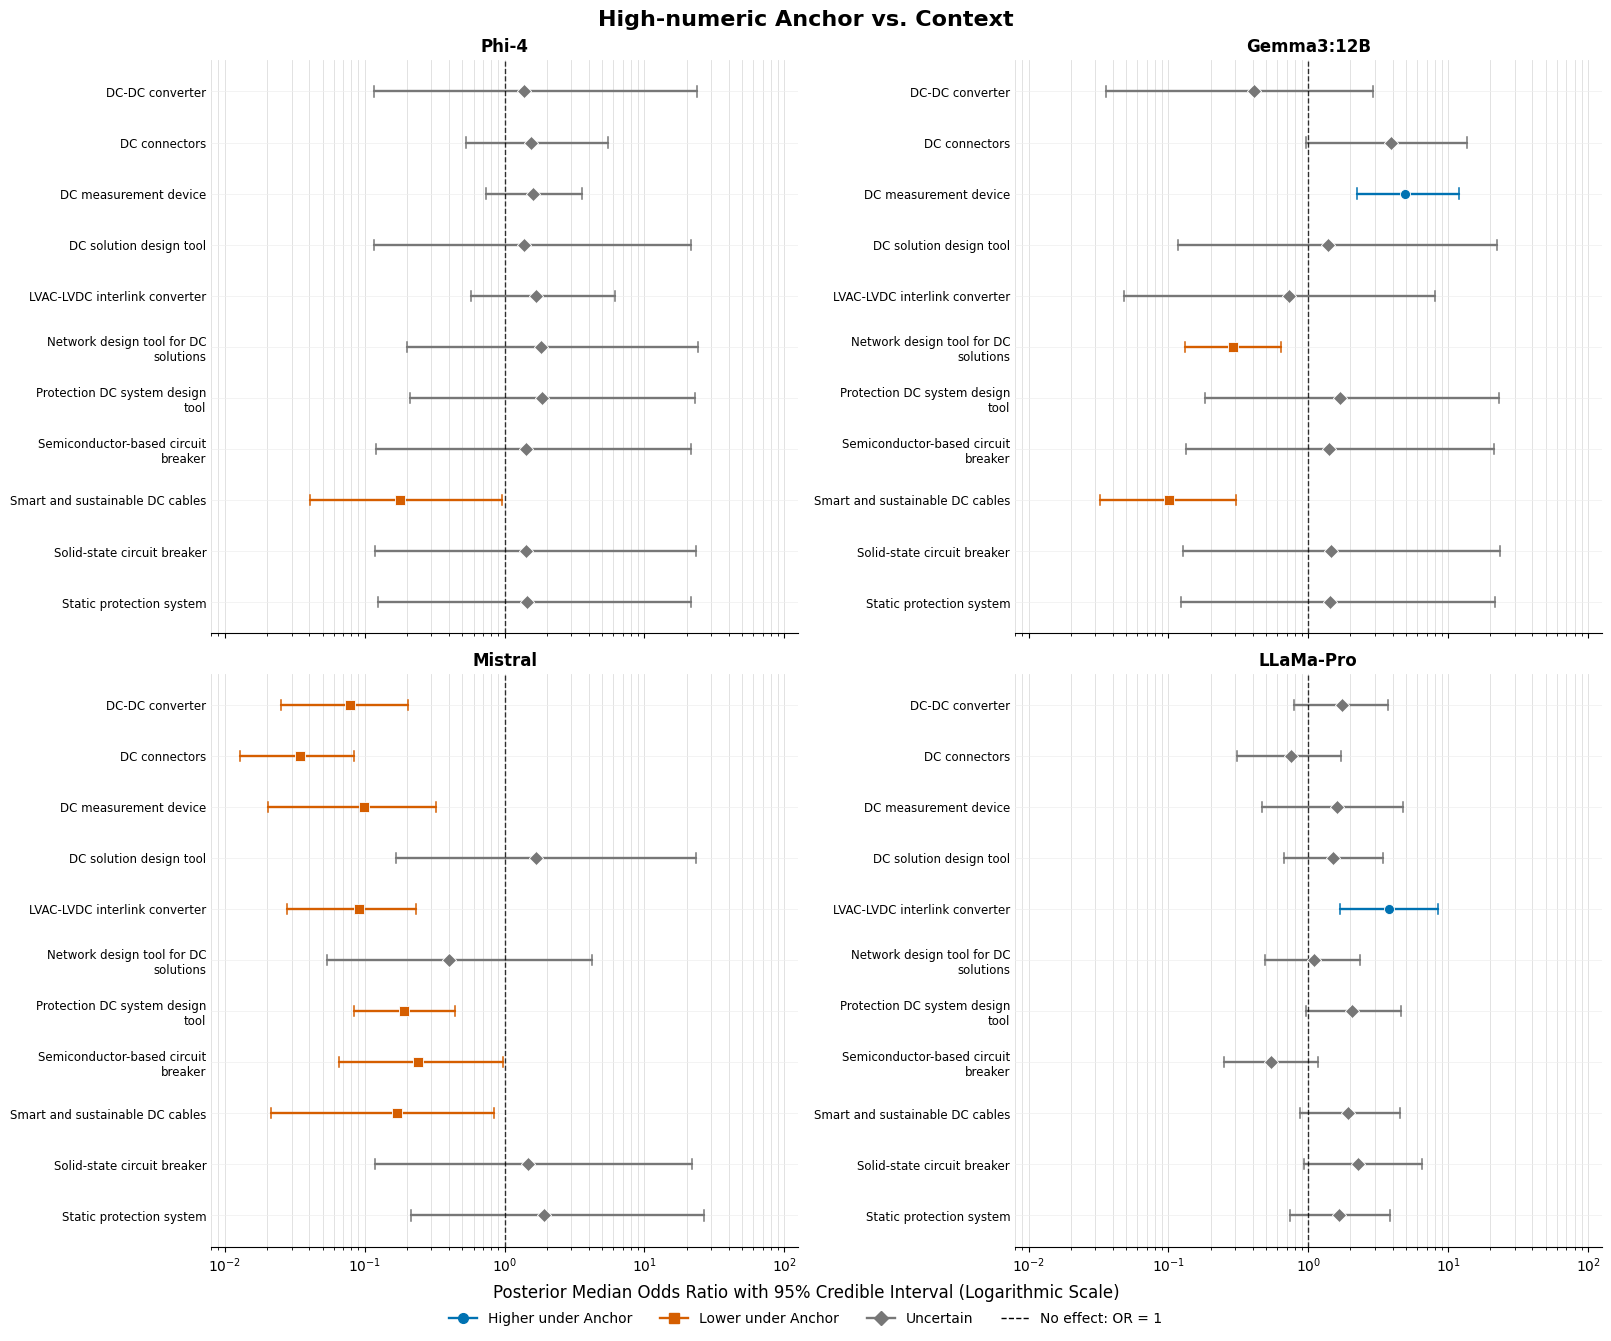

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.



Saved Low-numeric Anchor:
/Users/HP/Documents/second-publication/current-analysis/re-run/rq3-rerun/imp-ctx-anchor-working/rq3_importance_primary_forest_anchor_num_low.png
/Users/HP/Documents/second-publication/current-analysis/re-run/rq3-rerun/imp-ctx-anchor-working/rq3_importance_primary_forest_anchor_num_low.eps


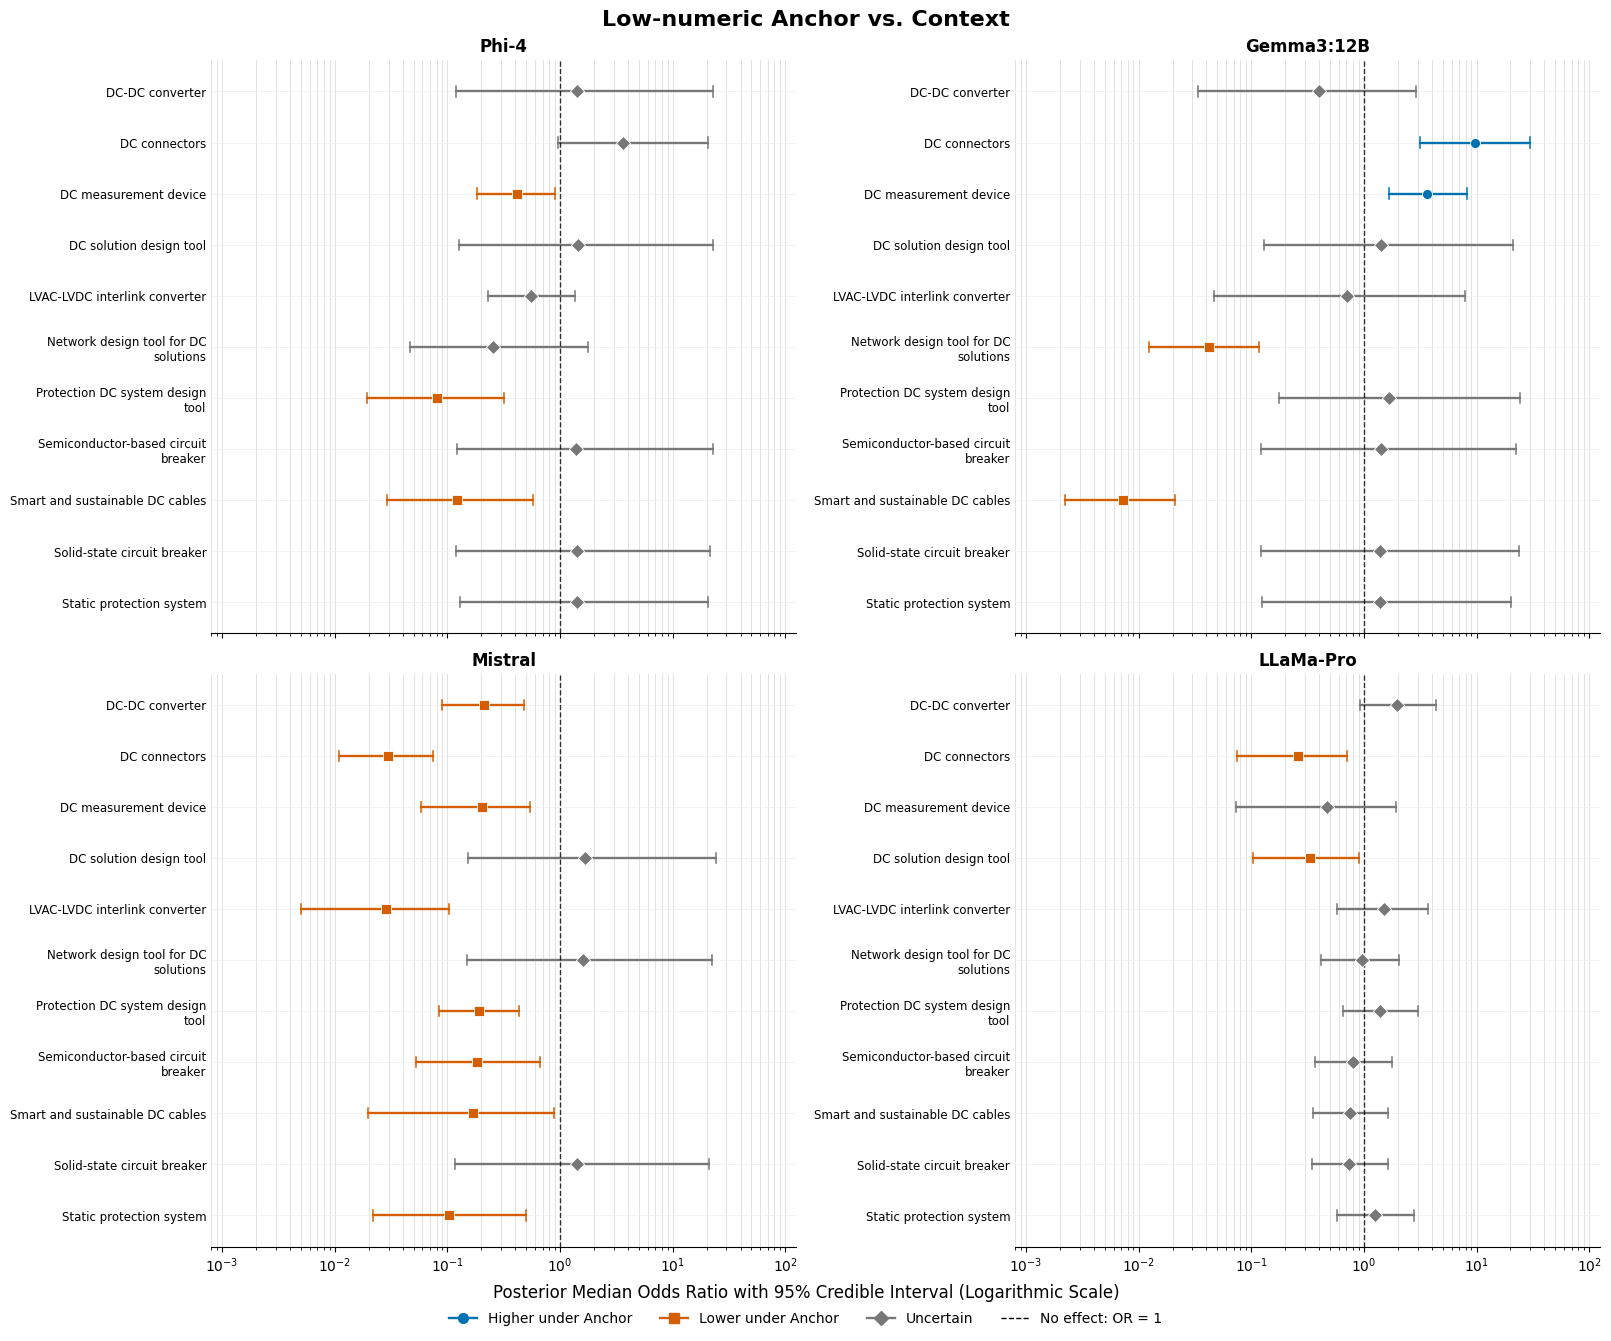

In [10]:
# the four forest plots for the paper: Primary-prior forest plots for the main paper

style_map = {
    "higher under Anchor": {
        "label": "Higher under Anchor",
        "colour": "#0072B2",
        "marker": "o",
    },
    "lower under Anchor": {
        "label": "Lower under Anchor",
        "colour": "#D55E00",
        "marker": "s",
    },
    "uncertain": {
        "label": "Uncertain",
        "colour": "#777777",
        "marker": "D",
    },
}

unexpected_conclusions = set(
    primary["conclusion"]
).difference(style_map)

if unexpected_conclusions:
    raise ValueError(
        "Unexpected conclusion values: "
        + ", ".join(sorted(unexpected_conclusions))
    )

if (
    primary[
        ["OR_median", "OR_l95", "OR_u95"]
    ] <= 0
).any().any():
    raise ValueError(
        "Odds ratios must be positive for logarithmic plots."
    )

wrapped_solution_labels = {
    solution: textwrap.fill(
        str(solution),
        width=31,
    )
    for solution in solution_order
}

forest_outputs = {}

for anchor_type in anchor_order:
    anchor_data = primary.loc[
        primary["anchor_type"].eq(anchor_type)
    ].copy()

    x_min = 10 ** np.floor(
        np.log10(anchor_data["OR_l95"].min())
    )

    x_max = 10 ** np.ceil(
        np.log10(anchor_data["OR_u95"].max())
    )

    x_min = x_min / 1.25
    x_max = x_max * 1.25

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(16, 13),
        sharex=True,
        constrained_layout=True,
    )

    axes = axes.flatten()

    for axis, base_model in zip(
        axes,
        model_order,
    ):
        model_data = (
            anchor_data.loc[
                anchor_data["base_model"].eq(
                    base_model
                )
            ]
            .sort_values("_solution_order")
            .reset_index(drop=True)
        )

        if len(model_data) != 11:
            raise ValueError(
                f"Expected 11 solutions for "
                f"{base_model}/{anchor_type}, "
                f"found {len(model_data)}."
            )

        y_positions = np.arange(len(model_data))

        for row_number, row in model_data.iterrows():
            style = style_map[row["conclusion"]]

            axis.plot(
                [row["OR_l95"], row["OR_u95"]],
                [row_number, row_number],
                color=style["colour"],
                linewidth=1.7,
                solid_capstyle="round",
                zorder=2,
            )

            axis.plot(
                [row["OR_l95"], row["OR_l95"]],
                [row_number - 0.10, row_number + 0.10],
                color=style["colour"],
                linewidth=1.1,
                zorder=2,
            )

            axis.plot(
                [row["OR_u95"], row["OR_u95"]],
                [row_number - 0.10, row_number + 0.10],
                color=style["colour"],
                linewidth=1.1,
                zorder=2,
            )

            axis.scatter(
                row["OR_median"],
                row_number,
                color=style["colour"],
                marker=style["marker"],
                s=52,
                edgecolor="white",
                linewidth=0.6,
                zorder=3,
            )

        axis.axvline(
            1,
            color="black",
            linestyle="--",
            linewidth=1,
            alpha=0.8,
        )

        axis.set_xscale("log")
        axis.set_xlim(x_min, x_max)

        axis.set_yticks(y_positions)
        axis.set_yticklabels(
            [
                wrapped_solution_labels[
                    solution
                ]
                for solution in model_data[
                    "dc_solution"
                ]
            ],
            fontsize=8.5,
        )

        axis.invert_yaxis()

        axis.set_title(
            model_labels[base_model],
            fontsize=12,
            fontweight="bold",
        )

        axis.grid(
            axis="x",
            which="both",
            color="#DDDDDD",
            linewidth=0.6,
        )

        axis.grid(
            axis="y",
            color="#EEEEEE",
            linewidth=0.5,
        )

        axis.tick_params(
            axis="y",
            length=0,
        )

        axis.spines["top"].set_visible(False)
        axis.spines["right"].set_visible(False)
        axis.spines["left"].set_visible(False)

    fig.suptitle(
        f"{anchor_labels[anchor_type]} vs. Context",
        fontsize=16,
        fontweight="bold",
    )

    fig.supxlabel(
        "Posterior Median Odds Ratio with 95% Credible Interval "
        "(Logarithmic Scale)",
        fontsize=12,
    )

    legend_handles = [
        Line2D(
            [0],
            [0],
            color=style_map[
                "higher under Anchor"
            ]["colour"],
            marker=style_map[
                "higher under Anchor"
            ]["marker"],
            linewidth=1.7,
            markersize=7,
            label="Higher under Anchor",
        ),
        Line2D(
            [0],
            [0],
            color=style_map[
                "lower under Anchor"
            ]["colour"],
            marker=style_map[
                "lower under Anchor"
            ]["marker"],
            linewidth=1.7,
            markersize=7,
            label="Lower under Anchor",
        ),
        Line2D(
            [0],
            [0],
            color=style_map["uncertain"]["colour"],
            marker=style_map["uncertain"]["marker"],
            linewidth=1.7,
            markersize=7,
            label="Uncertain",
        ),
        Line2D(
            [0],
            [0],
            color="black",
            linestyle="--",
            linewidth=1,
            label="No effect: OR = 1",
        ),
    ]

    fig.legend(
        handles=legend_handles,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.025),
        ncol=4,
        frameon=False,
        fontsize=10,
    )

    filename_label = anchor_filename_labels[
        anchor_type
    ]

    png_path = (
        working_dir
        / (
            "rq3_importance_primary_forest_"
            f"{filename_label}.png"
        )
    )

    eps_path = (
        working_dir
        / (
            "rq3_importance_primary_forest_"
            f"{filename_label}.eps"
        )
    )

    fig.savefig(
        png_path,
        dpi=300,
        bbox_inches="tight",
        facecolor="white",
    )

    fig.savefig(
        eps_path,
        format="eps",
        dpi=600,
        bbox_inches="tight",
        facecolor="white",
    )

    forest_outputs[anchor_type] = {
        "png": png_path,
        "eps": eps_path,
    }

    print(f"\nSaved {anchor_labels[anchor_type]}:")
    print(png_path.resolve())
    print(eps_path.resolve())

    plt.show()
    plt.close(fig)

In [12]:
# RQ3 importance: compact primary-prior summary table
# Representation: main-paper H/L/U classification counts

from pathlib import Path
import pandas as pd
from IPython.display import display

working_dir = Path("imp-ctx-anchor-working")

input_path = (
    working_dir
    / "bayesian-results"
    / "prior-sensitivity"
    / "rq3_importance_prior_sensitivity_effects.csv"
)

output_path = (
    working_dir
    / "rq3_importance_primary_compact_summary_table.tex"
)

if not input_path.exists():
    raise FileNotFoundError(
        "RQ3 importance sensitivity effects were not found:\n"
        f"{input_path.resolve()}"
    )

model_labels = {
    "gemma3": "Gemma3:12B",
    "llama": "LLaMa-Pro",
    "mistral": "Mistral",
    "phi4": "Phi-4",
}

model_order = [
    "phi4",
    "gemma3",
    "mistral",
    "llama",
]

anchor_labels = {
    "ANCHOR_EXAMPLE": "Example",
    "ANCHOR_WORD": "Word",
    "ANCHOR_NUM_HIGH": "High numeric",
    "ANCHOR_NUM_LOW": "Low numeric",
}

anchor_order = [
    "ANCHOR_EXAMPLE",
    "ANCHOR_WORD",
    "ANCHOR_NUM_HIGH",
    "ANCHOR_NUM_LOW",
]

expected_conclusions = {
    "higher under Anchor",
    "lower under Anchor",
    "uncertain",
}

# Read and validate the primary-prior effects
effects = pd.read_csv(input_path)

required_columns = {
    "prior_name",
    "base_model",
    "dc_solution",
    "anchor_type",
    "conclusion",
}

missing_columns = required_columns.difference(
    effects.columns
)

if missing_columns:
    raise ValueError(
        "Missing required columns: "
        + ", ".join(sorted(missing_columns))
    )

primary = effects.loc[
    effects["prior_name"].eq("primary")
].copy()

if len(primary) != 176:
    raise ValueError(
        "Expected 176 primary-prior effects "
        "(4 models × 4 anchor types × 11 DC solutions), "
        f"found {len(primary)}."
    )

if set(primary["base_model"]) != set(model_order):
    raise ValueError(
        "The expected four base models were not found."
    )

if set(primary["anchor_type"]) != set(anchor_order):
    raise ValueError(
        "The expected four anchor types were not found."
    )

unexpected_conclusions = set(
    primary["conclusion"]
).difference(expected_conclusions)

if unexpected_conclusions:
    raise ValueError(
        "Unexpected conclusion values: "
        + ", ".join(sorted(unexpected_conclusions))
    )

if primary.duplicated(
    subset=[
        "base_model",
        "anchor_type",
        "dc_solution",
    ]
).any():
    raise ValueError(
        "Duplicate base-model/anchor/DC-solution effects found."
    )

# --------------------------------------------------------------
# Count H/L/U conclusions for every model and anchor type
# --------------------------------------------------------------

records = []
audit_records = []

for base_model in model_order:
    record = {
        "Model": model_labels[base_model],
    }

    for anchor_type in anchor_order:
        group = primary.loc[
            primary["base_model"].eq(base_model)
            & primary["anchor_type"].eq(anchor_type)
        ]

        if len(group) != 11:
            raise ValueError(
                f"Expected 11 DC-solution effects for "
                f"{base_model}/{anchor_type}, found {len(group)}."
            )

        higher = int(
            group["conclusion"]
            .eq("higher under Anchor")
            .sum()
        )

        lower = int(
            group["conclusion"]
            .eq("lower under Anchor")
            .sum()
        )

        uncertain = int(
            group["conclusion"]
            .eq("uncertain")
            .sum()
        )

        if higher + lower + uncertain != 11:
            raise ValueError(
                "H/L/U counts do not sum to 11 for "
                f"{base_model}/{anchor_type}."
            )

        # Compact table cell: Higher / Lower / Uncertain
        record[anchor_labels[anchor_type]] = (
            f"{higher}/{lower}/{uncertain}"
        )

        audit_records.append({
            "base_model": base_model,
            "anchor_type": anchor_type,
            "higher": higher,
            "lower": lower,
            "uncertain": uncertain,
            "total": higher + lower + uncertain,
        })

    records.append(record)

table = pd.DataFrame(records)
audit = pd.DataFrame(audit_records)

# --------------------------------------------------------------
# Generate the compact LaTeX table
# --------------------------------------------------------------

latex = table.to_latex(
    index=False,
    escape=False,
    column_format="lcccc",
    caption=(
        "RQ3 importance effects by base model and anchor type "
        "under the primary prior."
    ),
    label="tab:rq3_importance_primary_compact",
    position="tbp",
)

note = (
    "\\end{tabular}\n"
    "\\vspace{2pt}\n"
    "\\begin{minipage}{\\linewidth}\n"
    "\\footnotesize\\textit{Note.} "
    "Each cell reports H/L/U: the numbers of DC-solution "
    "contrasts classified as higher under Anchor, lower under "
    "Anchor, and uncertain, respectively. Each cell summarizes "
    "11 separately estimated DC-solution effects and therefore "
    "sums to 11. The effects were not pooled across DC solutions. "
    "Classifications were obtained from the primary-prior "
    "posterior estimates.\n"
    "\\end{minipage}"
)

latex = latex.replace(
    "\\end{tabular}",
    note,
    1,
)

output_path.write_text(
    latex,
    encoding="utf-8",
)

print(
    "RQ3 importance compact main-paper table saved to:\n"
    f"{output_path.resolve()}"
)

print("\nCompact H/L/U table:")
display(table)

print("\nUnderlying count audit:")
display(audit)

RQ3 importance compact main-paper table saved to:
/Users/HP/Documents/second-publication/current-analysis/re-run/rq3-rerun/imp-ctx-anchor-working/rq3_importance_primary_compact_summary_table.tex

Compact H/L/U table:


,Model,Example,Word,High numeric,Low numeric
0,Phi-4,0/0/11,3/0/8,0/1/10,0/3/8
1,Gemma3:12B,1/3/7,4/0/7,1/2/8,2/2/7
2,Mistral,0/2/9,0/3/8,0/7/4,0/8/3
3,LLaMa-Pro,0/2/9,1/1/9,1/0/10,0/2/9



Underlying count audit:


,base_model,anchor_type,higher,lower,uncertain,total
0,phi4,ANCHOR_EXAMPLE,0,0,11,11
1,phi4,ANCHOR_WORD,3,0,8,11
2,phi4,ANCHOR_NUM_HIGH,0,1,10,11
3,phi4,ANCHOR_NUM_LOW,0,3,8,11
4,gemma3,ANCHOR_EXAMPLE,1,3,7,11
5,gemma3,ANCHOR_WORD,4,0,7,11
6,gemma3,ANCHOR_NUM_HIGH,1,2,8,11
7,gemma3,ANCHOR_NUM_LOW,2,2,7,11
8,mistral,ANCHOR_EXAMPLE,0,2,9,11
9,mistral,ANCHOR_WORD,0,3,8,11


In [13]:
# primary-model ppc summary table for the online appendix
ppc_input_path = (
    working_dir
    / "bayesian-results"
    / "base-solution-threshold"
    / "posterior-predictive-checks"
    / "rq3_importance_base_solution_threshold_ppc_summary.csv"
)

ppc_output_path = (
    working_dir
    / "rq3_importance_primary_ppc_summary_table.tex"
)

if not ppc_input_path.exists():
    raise FileNotFoundError(
        "RQ3 importance PPC summary was not found:\n"
        f"{ppc_input_path.resolve()}"
    )

ppc = pd.read_csv(ppc_input_path)

require_columns(
    ppc,
    {
        "base_model",
        "comparison",
        "category_checks",
        "checks_within_predictive_95",
        "proportion_within_predictive_95",
        "median_absolute_difference",
        "maximum_absolute_difference",
    },
    "RQ3 importance PPC summary",
)

if len(ppc) != 21:
    raise ValueError(
        "Expected 21 PPC summary rows, "
        f"found {len(ppc)}."
    )

comparison_labels = {
    "CONTEXT": "Context",
    "ANCHOR_EXAMPLE": "Example anchor",
    "ANCHOR_WORD": "Word anchor",
    "ANCHOR_NUM_HIGH": "High-numeric anchor",
    "ANCHOR_NUM_LOW": "Low-numeric anchor",
    "all": "Overall",
}

comparison_order = [
    "CONTEXT",
    "ANCHOR_EXAMPLE",
    "ANCHOR_WORD",
    "ANCHOR_NUM_HIGH",
    "ANCHOR_NUM_LOW",
    "all",
]

ppc_model_labels = {
    **model_labels,
    "all": "Overall",
}

ppc_model_order = model_order + ["all"]

ppc["_model_order"] = ppc["base_model"].map({
    value: index
    for index, value in enumerate(ppc_model_order)
})

ppc["_comparison_order"] = ppc[
    "comparison"
].map({
    value: index
    for index, value in enumerate(comparison_order)
})

if ppc[
    ["_model_order", "_comparison_order"]
].isna().any().any():
    raise ValueError(
        "Unexpected model or comparison labels in PPC summary."
    )

ppc = (
    ppc
    .sort_values([
        "_model_order",
        "_comparison_order",
    ])
    .reset_index(drop=True)
)

ppc_table = pd.DataFrame({
    "Model": ppc["base_model"].map(
        ppc_model_labels
    ),

    "Comparison group": ppc["comparison"].map(
        comparison_labels
    ),

    "Within 95\\% PPI": [
        f"{within}/{total}"
        for within, total in zip(
            ppc["checks_within_predictive_95"],
            ppc["category_checks"],
        )
    ],

    "Coverage": ppc[
        "proportion_within_predictive_95"
    ].map(
        lambda value: f"{100 * value:.1f}\\%"
    ),

    "Median absolute difference": ppc[
        "median_absolute_difference"
    ].map(
        lambda value: f"{value:.3f}"
    ),

    "Maximum absolute difference": ppc[
        "maximum_absolute_difference"
    ].map(
        lambda value: f"{value:.3f}"
    ),
})

ppc_latex = ppc_table.to_latex(
    index=False,
    escape=False,
    column_format=(
        r"p{2.1cm}"
        r"p{2.8cm}"
        r"c"
        r"c"
        r"c"
        r"c"
    ),
    caption=(
        "Posterior predictive checks for the RQ3 importance "
        "primary model."
    ),
    label="tab:rq3_importance_primary_ppc",
    position="tbp",
)

ppc_latex = add_table_note(
    ppc_latex,
    (
        "PPI denotes the 95\\% posterior predictive interval. "
        "Coverage is the proportion of observed rating-category "
        "proportions within their corresponding PPIs. Absolute "
        "differences compare observed proportions with posterior-"
        "predicted median proportions."
    ),
)

ppc_output_path.write_text(
    ppc_latex,
    encoding="utf-8",
)

print(f"Saved to:\n{ppc_output_path.resolve()}")
display(ppc_table)

Saved to:
/Users/HP/Documents/second-publication/current-analysis/re-run/rq3-rerun/imp-ctx-anchor-working/rq3_importance_primary_ppc_summary_table.tex


,Model,Comparison group,Within 95\% PPI,Coverage,Median absolute difference,Maximum absolute difference
0,Phi-4,Context,22/22,100.0\%,0.007,0.013
1,Phi-4,Example anchor,22/22,100.0\%,0.000,0.033
2,Phi-4,Word anchor,22/22,100.0\%,0.000,0.033
3,Phi-4,High-numeric anchor,22/22,100.0\%,0.000,0.033
4,Phi-4,Low-numeric anchor,22/22,100.0\%,0.000,0.067
5,Gemma3:12B,Context,22/22,100.0\%,0.007,0.027
6,Gemma3:12B,Example anchor,22/22,100.0\%,0.000,0.033
7,Gemma3:12B,Word anchor,22/22,100.0\%,0.000,0.067
8,Gemma3:12B,High-numeric anchor,22/22,100.0\%,0.000,0.033
9,Gemma3:12B,Low-numeric anchor,22/22,100.0\%,0.000,0.067


In [14]:
# This recomputes stability rates correctly from the 176 detailed records.
# prior-sensitivity summary and exceptions
robustness_input_path = (
    working_dir
    / "bayesian-results"
    / "prior-sensitivity"
    / "rq3_importance_prior_sensitivity_robustness.csv"
)

summary_output_path = (
    working_dir
    / "rq3_importance_prior_sensitivity_summary_table.tex"
)

exceptions_output_path = (
    working_dir
    / "rq3_importance_prior_sensitive_contrasts_table.tex"
)

if not robustness_input_path.exists():
    raise FileNotFoundError(
        "RQ3 importance robustness output was not found:\n"
        f"{robustness_input_path.resolve()}"
    )

robustness = pd.read_csv(robustness_input_path)

require_columns(
    robustness,
    {
        "base_model",
        "dc_solution",
        "anchor_type",
        "direction_stable",
        "conclusion_stable",
        "OR_median_regularizing",
        "OR_l95_regularizing",
        "OR_u95_regularizing",
        "OR_median_primary",
        "OR_l95_primary",
        "OR_u95_primary",
        "OR_median_weak",
        "OR_l95_weak",
        "OR_u95_weak",
        "conclusion_regularizing",
        "conclusion_primary",
        "conclusion_weak",
    },
    "RQ3 importance robustness output",
)

if len(robustness) != 176:
    raise ValueError(
        "Expected 176 robustness records, "
        f"found {len(robustness)}."
    )

for column in [
    "direction_stable",
    "conclusion_stable",
]:
    if robustness[column].dtype != bool:
        robustness[column] = (
            robustness[column]
            .astype(str)
            .str.upper()
            .map({
                "TRUE": True,
                "FALSE": False,
            })
        )

    if robustness[column].isna().any():
        raise ValueError(
            f"Could not interpret {column} as logical."
        )

summary_records = []

for base_model in model_order:
    for anchor_type in anchor_order:
        group = robustness.loc[
            robustness["base_model"].eq(base_model)
            & robustness["anchor_type"].eq(anchor_type)
        ]

        if len(group) != 11:
            raise ValueError(
                f"Expected 11 contrasts for "
                f"{base_model}/{anchor_type}; found {len(group)}."
            )

        total = len(group)
        direction_count = int(
            group["direction_stable"].sum()
        )
        conclusion_count = int(
            group["conclusion_stable"].sum()
        )

        summary_records.append({
            "Model": model_labels[base_model],
            "Anchor type": anchor_short_labels[
                anchor_type
            ],
            "Contrasts": total,
            "Direction stable": (
                f"{direction_count}/{total} "
                f"({100 * direction_count / total:.1f}\\%)"
            ),
            "Conclusion stable": (
                f"{conclusion_count}/{total} "
                f"({100 * conclusion_count / total:.1f}\\%)"
            ),
        })

total = len(robustness)
direction_count = int(
    robustness["direction_stable"].sum()
)
conclusion_count = int(
    robustness["conclusion_stable"].sum()
)

summary_records.append({
    "Model": "Overall",
    "Anchor type": "All",
    "Contrasts": total,
    "Direction stable": (
        f"{direction_count}/{total} "
        f"({100 * direction_count / total:.1f}\\%)"
    ),
    "Conclusion stable": (
        f"{conclusion_count}/{total} "
        f"({100 * conclusion_count / total:.1f}\\%)"
    ),
})

sensitivity_summary = pd.DataFrame(
    summary_records
)

summary_latex = sensitivity_summary.to_latex(
    index=False,
    escape=False,
    column_format="llccc",
    caption=(
        "Prior-sensitivity summary for the RQ3 importance "
        "anchor effects."
    ),
    label="tab:rq3_importance_prior_sensitivity",
    position="tbp",
)

summary_latex = add_table_note(
    summary_latex,
    (
        "Direction stability indicates that the posterior median "
        "OR remained on the same side of one under the "
        "regularizing, primary, and weak priors. Conclusion "
        "stability indicates that the inferential classification "
        "was identical under all three priors. Rates were "
        "calculated directly from the 176 contrast-level records."
    ),
)

summary_output_path.write_text(
    summary_latex,
    encoding="utf-8",
)

# --------------------------------------------------------------
# Prior-dependent exceptions
# --------------------------------------------------------------

exceptions = robustness.loc[
    ~robustness["direction_stable"]
    | ~robustness["conclusion_stable"]
].copy()


def format_prior_cell(row, prior_name):
    median = format_number(
        row[f"OR_median_{prior_name}"]
    )
    lower = format_number(
        row[f"OR_l95_{prior_name}"]
    )
    upper = format_number(
        row[f"OR_u95_{prior_name}"]
    )
    conclusion = conclusion_labels[
        row[f"conclusion_{prior_name}"]
    ]

    return (
        f"{median} [{lower}, {upper}]; "
        f"{conclusion}"
    )


if exceptions.empty:
    exceptions_table = pd.DataFrame({
        "Result": [
            "All 176 contrasts were stable across priors."
        ]
    })

    exception_column_format = "p{15cm}"
else:
    exceptions["_model_order"] = exceptions[
        "base_model"
    ].map(model_rank)

    exceptions["_anchor_order"] = exceptions[
        "anchor_type"
    ].map({
        value: index
        for index, value in enumerate(anchor_order)
    })

    exceptions["_solution_order"] = exceptions[
        "dc_solution"
    ].map(solution_rank)

    exceptions = (
        exceptions
        .sort_values([
            "_model_order",
            "_anchor_order",
            "_solution_order",
        ])
        .reset_index(drop=True)
    )

    exceptions_table = pd.DataFrame({
        "Model": exceptions["base_model"].map(
            model_labels
        ),

        "Anchor type": exceptions["anchor_type"].map(
            anchor_short_labels
        ),

        "DC solution": exceptions["dc_solution"],

        "Regularizing": [
            format_prior_cell(row, "regularizing")
            for _, row in exceptions.iterrows()
        ],

        "Primary": [
            format_prior_cell(row, "primary")
            for _, row in exceptions.iterrows()
        ],

        "Weak": [
            format_prior_cell(row, "weak")
            for _, row in exceptions.iterrows()
        ],
    })

    exception_column_format = (
        r"p{1.8cm}"
        r"p{2.0cm}"
        r"p{3.7cm}"
        r"p{3.7cm}"
        r"p{3.7cm}"
        r"p{3.7cm}"
    )

exceptions_latex = exceptions_table.to_latex(
    index=False,
    escape=False,
    longtable=not exceptions.empty,
    column_format=exception_column_format,
    caption=(
        "RQ3 importance contrasts with prior-dependent "
        "inferential conclusions."
    ),
    label="tab:rq3_importance_prior_sensitive_contrasts",
    position="tbp",
)

exceptions_latex = add_table_note(
    exceptions_latex,
    (
        "Cells report posterior median ORs, 95\\% credible "
        "intervals, and inferential conclusions. Only contrasts "
        "whose direction or conclusion differed across the "
        "regularizing, primary, and weak priors are listed."
    ),
    longtable=not exceptions.empty,
)

exceptions_output_path.write_text(
    exceptions_latex,
    encoding="utf-8",
)

print("Sensitivity tables saved to:")
print(summary_output_path.resolve())
print(exceptions_output_path.resolve())

print("\nSensitivity summary:")
display(sensitivity_summary)

print("\nPrior-dependent contrasts:")
display(exceptions_table)

Sensitivity tables saved to:
/Users/HP/Documents/second-publication/current-analysis/re-run/rq3-rerun/imp-ctx-anchor-working/rq3_importance_prior_sensitivity_summary_table.tex
/Users/HP/Documents/second-publication/current-analysis/re-run/rq3-rerun/imp-ctx-anchor-working/rq3_importance_prior_sensitive_contrasts_table.tex

Sensitivity summary:


,Model,Anchor type,Contrasts,Direction stable,Conclusion stable
0,Phi-4,Example,11,11/11 (100.0\%),11/11 (100.0\%)
1,Phi-4,Word,11,11/11 (100.0\%),10/11 (90.9\%)
2,Phi-4,High numeric,11,11/11 (100.0\%),10/11 (90.9\%)
3,Phi-4,Low numeric,11,11/11 (100.0\%),10/11 (90.9\%)
4,Gemma3:12B,Example,11,11/11 (100.0\%),9/11 (81.8\%)
5,Gemma3:12B,Word,11,11/11 (100.0\%),11/11 (100.0\%)
6,Gemma3:12B,High numeric,11,11/11 (100.0\%),10/11 (90.9\%)
7,Gemma3:12B,Low numeric,11,11/11 (100.0\%),11/11 (100.0\%)
8,Mistral,Example,11,10/11 (90.9\%),10/11 (90.9\%)
9,Mistral,Word,11,10/11 (90.9\%),10/11 (90.9\%)



Prior-dependent contrasts:


,Model,Anchor type,DC solution,Regularizing,Primary,Weak
0,Phi-4,Word,DC connectors,"2.764 [0.982, 8.945]; Uncertain","7.135 [1.515, 55.912]; Higher under Anchor","18.259 [2.161, 612.043]; Higher under Anchor"
1,Phi-4,High numeric,Smart and sustainable DC cables,"0.437 [0.140, 1.417]; Uncertain","0.180 [0.041, 0.957]; Lower under Anchor","0.104 [0.017, 0.657]; Lower under Anchor"
2,Phi-4,Low numeric,DC connectors,"2.092 [0.805, 6.264]; Uncertain","3.611 [0.956, 20.708]; Uncertain","5.046 [1.110, 51.317]; Higher under Anchor"
3,Gemma3:12B,Example,DC-DC converter,"2.366 [0.892, 6.010]; Uncertain","6.462 [1.759, 23.601]; Higher under Anchor","12.988 [2.815, 62.114]; Higher under Anchor"
4,Gemma3:12B,Example,Protection DC system design tool,"0.343 [0.102, 1.237]; Uncertain","0.124 [0.023, 0.700]; Lower under Anchor","0.073 [0.009, 0.496]; Lower under Anchor"
5,Gemma3:12B,High numeric,DC connectors,"1.636 [0.595, 4.111]; Uncertain","3.920 [0.959, 13.521]; Uncertain","7.591 [1.633, 35.109]; Higher under Anchor"
6,Mistral,Example,DC connectors,"0.426 [0.191, 1.019]; Uncertain","0.207 [0.079, 0.594]; Lower under Anchor","0.146 [0.050, 0.445]; Lower under Anchor"
7,Mistral,Example,Protection DC system design tool,"1.045 [0.466, 2.527]; Uncertain","0.913 [0.352, 2.654]; Uncertain","0.852 [0.325, 2.733]; Uncertain"
8,Mistral,Word,DC connectors,"1.325 [0.497, 4.001]; Uncertain","1.030 [0.290, 4.940]; Uncertain","0.815 [0.195, 5.322]; Uncertain"
9,Mistral,Word,Protection DC system design tool,"0.579 [0.272, 1.311]; Uncertain","0.440 [0.184, 1.097]; Uncertain","0.392 [0.164, 0.995]; Lower under Anchor"


In [18]:
# Selected high- and low-numeric importance effects for the main paper

from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import display

# Paths are relative to rq3-rerun/rq3-imp-analysis.ipynb
working_dir = Path("imp-ctx-anchor-working")

input_path = (
    working_dir
    / "bayesian-results"
    / "prior-sensitivity"
    / "primary"
    / "rq3_importance_primary_effects.csv"
)

output_path = (
    working_dir
    / "rq3_importance_selected_numeric_pairs_table.tex"
)

if not input_path.exists():
    raise FileNotFoundError(
        "Primary RQ3 importance effects were not found:\n"
        f"{input_path.resolve()}"
    )

model_labels = {
    "phi4": "Phi-4",
    "gemma3": "Gemma3:12B",
    "mistral": "Mistral",
    "llama": "LLaMa-Pro",
}

model_order = [
    "phi4",
    "gemma3",
    "mistral",
    "llama",
]

conclusion_labels = {
    "higher under Anchor": "Higher",
    "lower under Anchor": "Lower",
    "uncertain": "Uncertain",
}


def latex_escape(value):
    """Escape relevant LaTeX special characters in text fields."""
    value = str(value)

    replacements = {
        "&": r"\&",
        "%": r"\%",
        "#": r"\#",
        "_": r"\_",
    }

    for original, replacement in replacements.items():
        value = value.replace(original, replacement)

    return value


def format_effect(row, prefix):
    """Format an OR, its credible interval, and interpretation."""
    conclusion = conclusion_labels[
        row[f"{prefix}_conclusion"]
    ]

    return (
        f"{row[f'{prefix}_OR_median']:.3f} "
        f"[{row[f'{prefix}_OR_l95']:.3f}, "
        f"{row[f'{prefix}_OR_u95']:.3f}]; "
        f"{conclusion}"
    )


# --------------------------------------------------------------
# Read and validate the primary effects
# --------------------------------------------------------------

effects = pd.read_csv(input_path)

required_columns = {
    "prior_name",
    "base_model",
    "dc_solution",
    "anchor_type",
    "OR_median",
    "OR_l95",
    "OR_u95",
    "conclusion",
}

missing_columns = required_columns.difference(effects.columns)

if missing_columns:
    raise ValueError(
        "Missing required columns: "
        + ", ".join(sorted(missing_columns))
    )

primary = effects.loc[
    effects["prior_name"].eq("primary")
].copy()

if len(primary) != 176:
    raise ValueError(
        "Expected 176 primary-prior effects "
        "(4 models × 11 solutions × 4 anchors), "
        f"found {len(primary)}."
    )

expected_conclusions = set(conclusion_labels)

unexpected_conclusions = set(
    primary["conclusion"]
).difference(expected_conclusions)

if unexpected_conclusions:
    raise ValueError(
        "Unexpected conclusions: "
        + ", ".join(sorted(unexpected_conclusions))
    )

# --------------------------------------------------------------
# Extract and pair the high- and low-numeric effects
# --------------------------------------------------------------

pairing_keys = [
    "base_model",
    "dc_solution",
]

effect_columns = [
    "OR_median",
    "OR_l95",
    "OR_u95",
    "conclusion",
]

high = (
    primary.loc[
        primary["anchor_type"].eq("ANCHOR_NUM_HIGH"),
        pairing_keys + effect_columns,
    ]
    .rename(columns={
        column: f"high_{column}"
        for column in effect_columns
    })
)

low = (
    primary.loc[
        primary["anchor_type"].eq("ANCHOR_NUM_LOW"),
        pairing_keys + effect_columns,
    ]
    .rename(columns={
        column: f"low_{column}"
        for column in effect_columns
    })
)

if len(high) != 44 or len(low) != 44:
    raise ValueError(
        "Expected 44 high-numeric and 44 low-numeric effects; "
        f"found {len(high)} and {len(low)}, respectively."
    )

paired = high.merge(
    low,
    on=pairing_keys,
    how="inner",
    validate="one_to_one",
)

if len(paired) != 44:
    raise ValueError(
        f"Expected 44 paired numeric comparisons, found {len(paired)}."
    )

# --------------------------------------------------------------
# Retain informative pairs
#
# A pair is retained when at least one numeric arm has a supported
# effect relative to Context. This includes effects in either
# direction and avoids selecting only the expected pattern.
# --------------------------------------------------------------

selected = paired.loc[
    paired["high_conclusion"].ne("uncertain")
    | paired["low_conclusion"].ne("uncertain")
].copy()

if selected.empty:
    raise ValueError(
        "No numeric-anchor pairs had at least one "
        "non-uncertain effect."
    )

if len(selected) > len(paired):
    raise ValueError(
        "The selected-pair count cannot exceed the total "
        "number of paired comparisons."
    )

print(
    f"Selected {len(selected)} informative numeric pairs "
    f"from {len(paired)} total pairs."
)

selected["median_ordering"] = np.select(
    [
        selected["high_OR_median"].gt(
            selected["low_OR_median"]
        ),
        selected["high_OR_median"].lt(
            selected["low_OR_median"]
        ),
    ],
    [
        r"High $>$ Low",
        r"Low $>$ High",
    ],
    default="Equal",
)

model_rank = {
    model: rank
    for rank, model in enumerate(model_order)
}

selected["_model_order"] = selected[
    "base_model"
].map(model_rank)

selected = (
    selected
    .sort_values([
        "_model_order",
        "dc_solution",
    ])
    .reset_index(drop=True)
)

# --------------------------------------------------------------
# Construct the reporting table
# --------------------------------------------------------------

table = pd.DataFrame({
    "Model": selected["base_model"].map(model_labels),

    "DC solution": selected["dc_solution"].map(latex_escape),

    "High numeric vs. Context": [
        format_effect(row, "high")
        for _, row in selected.iterrows()
    ],

    "Low numeric vs. Context": [
        format_effect(row, "low")
        for _, row in selected.iterrows()
    ],

    "Median ordering": selected["median_ordering"],
})

if table.isna().any().any():
    raise ValueError(
        "The selected numeric-effects table contains missing values."
    )

# --------------------------------------------------------------
# Generate the LaTeX table
# --------------------------------------------------------------

latex = table.to_latex(
    index=False,
    escape=False,
    column_format=(
        r"p{1.8cm}"
        r"p{4.0cm}"
        r"p{3.7cm}"
        r"p{3.7cm}"
        r"p{1.8cm}"
    ),
    caption=(
        "Selected RQ3 importance numeric-anchor effects under "
        "the primary prior."
    ),
    label="tab:rq3-importance-selected-numeric",
    position="tbp",
)

# Use a double-column table
latex = latex.replace(
    r"\begin{table}[tbp]",
    r"\begin{table*}[tbp]",
    1,
)

latex = latex.replace(
    r"\end{table}",
    r"\end{table*}",
    1,
)

note = (
    "\\vspace{2pt}\n"
    "\\begin{minipage}{\\linewidth}\n"
    "\\footnotesize\\textit{Note.} "
    "Each high- and low-numeric odds ratio compares the named "
    "anchor arm with Context, for which the reference value is "
    "$OR=1$. Rows are included when at least one numeric-anchor "
    "effect was classified as higher or lower relative to Context; "
    "combinations for which both effects were uncertain are omitted. "
    "The final column compares the posterior median odds ratios "
    "descriptively and does not represent a direct posterior "
    "high-versus-low contrast. Each effect is reported as the "
    "posterior median OR, 95\\% credible interval, and interpretation.\n"
    "\\end{minipage}\n"
)

latex = latex.replace(
    "\\end{tabular}\n",
    "\\end{tabular}\n" + note,
    1,
)

output_path.write_text(
    latex,
    encoding="utf-8",
)

print(
    "Selected RQ3 importance numeric table saved to:\n"
    f"{output_path.resolve()}"
)

print(
    "\nSelected paired rows: "
    f"{len(selected)}/44"
)

print("\nSelected rows by base model:")
display(
    selected.groupby("base_model")
    .size()
    .reindex(model_order, fill_value=0)
    .rename("Selected pairs")
    .to_frame()
)

display(table)

Selected 18 informative numeric pairs from 44 total pairs.
Selected RQ3 importance numeric table saved to:
/Users/HP/Documents/second-publication/current-analysis/re-run/rq3-rerun/imp-ctx-anchor-working/rq3_importance_selected_numeric_pairs_table.tex

Selected paired rows: 18/44

Selected rows by base model:


,Selected pairs
base_model,
phi4,3
gemma3,4
mistral,8
llama,3


,Model,DC solution,High numeric vs. Context,Low numeric vs. Context,Median ordering
0,Phi-4,DC measurement device,"1.586 [0.732, 3.586]; Uncertain","0.417 [0.184, 0.900]; Lower",High $>$ Low
1,Phi-4,Protection DC system design tool,"1.858 [0.211, 22.999]; Uncertain","0.080 [0.019, 0.321]; Lower",High $>$ Low
2,Phi-4,Smart and sustainable DC cables,"0.180 [0.041, 0.957]; Lower","0.122 [0.029, 0.572]; Lower",High $>$ Low
3,Gemma3:12B,DC connectors,"3.920 [0.959, 13.521]; Uncertain","9.773 [3.162, 29.903]; Higher",Low $>$ High
4,Gemma3:12B,DC measurement device,"4.947 [2.210, 12.035]; Higher","3.609 [1.654, 8.280]; Higher",High $>$ Low
5,Gemma3:12B,Network design tool for DC solutions,"0.290 [0.131, 0.635]; Lower","0.042 [0.012, 0.117]; Lower",High $>$ Low
6,Gemma3:12B,Smart and sustainable DC cables,"0.102 [0.032, 0.302]; Lower","0.007 [0.002, 0.021]; Lower",High $>$ Low
7,Mistral,DC connectors,"0.034 [0.013, 0.083]; Lower","0.030 [0.011, 0.075]; Lower",High $>$ Low
8,Mistral,DC measurement device,"0.098 [0.020, 0.325]; Lower","0.202 [0.059, 0.538]; Lower",Low $>$ High
9,Mistral,DC-DC converter,"0.078 [0.025, 0.204]; Lower","0.213 [0.090, 0.477]; Lower",Low $>$ High


In [15]:
# anchor effects per anchor arm

from pathlib import Path
import pandas as pd
from IPython.display import display

working_dir = Path("imp-ctx-anchor-working")
results_dir = (
    working_dir
    / "bayesian-results"
    / "anchor-response-patterns"
)
output_dir = results_dir / "latex-tables"
output_dir.mkdir(parents=True, exist_ok=True)

primary_upper_path = (
    results_dir
    / "rq3_importance_primary_upper_end_contrasts.csv"
)
primary_numeric_path = (
    results_dir
    / "rq3_importance_primary_numeric_anchoring_patterns.csv"
)
upper_robustness_path = (
    results_dir
    / "rq3_importance_upper_end_robustness.csv"
)
numeric_robustness_path = (
    results_dir
    / "rq3_importance_numeric_anchoring_robustness.csv"
)

required_paths = [
    primary_upper_path,
    primary_numeric_path,
    upper_robustness_path,
    numeric_robustness_path,
]

missing_paths = [p for p in required_paths if not p.exists()]
if missing_paths:
    raise FileNotFoundError(
        "Missing RQ3 importance results:\n"
        + "\n".join(str(p.resolve()) for p in missing_paths)
    )

model_labels = {
    "gemma3": "Gemma3:12B",
    "llama": "LLaMa-Pro",
    "mistral": "Mistral",
    "phi4": "Phi-4",
}
model_order = ["phi4", "gemma3", "mistral", "llama"]

anchor_labels = {
    "ANCHOR_EXAMPLE": "Example",
    "ANCHOR_WORD": "Word",
}

upper_labels = {
    "greater upper-end concentration under Anchor": "Greater",
    "reduced upper-end concentration under Anchor": "Reduced",
    "uncertain": "Uncertain",
}

pattern_labels = {
    "complete directional anchoring": "Complete directional",
    "high-arm-only adjustment": "High arm only",
    "low-arm-only adjustment": "Low arm only",
    "directionally inconsistent": "Directionally inconsistent",
    "no supported adjustment": "No supported adjustment",
}

pattern_order = [
    "complete directional anchoring",
    "high-arm-only adjustment",
    "low-arm-only adjustment",
    "directionally inconsistent",
    "no supported adjustment",
]


def latex_escape(value):
    value = str(value)
    replacements = {
        "\\": r"\textbackslash{}",
        "&": r"\&",
        "%": r"\%",
        "$": r"\$",
        "#": r"\#",
        "_": r"\_",
        "{": r"\{",
        "}": r"\}",
    }
    for old, new in replacements.items():
        value = value.replace(old, new)
    return value


def format_probability(value):
    value = float(value)
    if value >= 0.9995:
        return r"$>0.999$"
    if value <= 0.0005:
        return r"$<0.001$"
    return f"{value:.3f}"


def format_or_interval(row, prefix):
    return (
        f"{row[f'{prefix}_OR_median']:.3f} "
        f"[{row[f'{prefix}_OR_l95']:.3f}, "
        f"{row[f'{prefix}_OR_u95']:.3f}]"
    )


def save_regular_table(
    table,
    path,
    caption,
    label,
    column_format,
    note,
    wide=False,
):
    latex = table.to_latex(
        index=False,
        escape=False,
        column_format=column_format,
        caption=caption,
        label=label,
        position="tbp",
    )

    note_block = (
        "\n\\vspace{2pt}\n"
        "\\begin{minipage}{\\linewidth}\n"
        "\\footnotesize\\textit{Note.} "
        + note
        + "\n\\end{minipage}"
    )

    latex = latex.replace(
        "\\end{tabular}",
        "\\end{tabular}" + note_block,
        1,
    )

    if wide:
        latex = latex.replace(
            "\\begin{table}",
            "\\begin{table*}",
            1,
        )
        latex = latex.replace(
            "\\end{table}",
            "\\end{table*}",
            1,
        )

    path.write_text(latex, encoding="utf-8")


def save_landscape_longtable(
    table,
    path,
    caption,
    label,
    column_format,
    note,
):
    latex = table.to_latex(
        index=False,
        escape=False,
        longtable=True,
        column_format=column_format,
        caption=caption,
        label=label,
    )

    note_row = (
        "\\midrule\n"
        f"\\multicolumn{{{len(table.columns)}}}"
        "{p{0.96\\linewidth}}"
        "{\\footnotesize\\textit{Note.} "
        + note
        + "}\\\\\n"
    )

    latex = latex.replace(
        "\\end{longtable}",
        note_row + "\\end{longtable}",
        1,
    )

    latex = (
        "\\begin{landscape}\n"
        + latex
        + "\\end{landscape}\n"
    )

    path.write_text(latex, encoding="utf-8")


# ------------------------------------------------------------------
# Read and validate results
# ------------------------------------------------------------------

upper = pd.read_csv(primary_upper_path)
numeric = pd.read_csv(primary_numeric_path)
upper_robustness = pd.read_csv(upper_robustness_path)
numeric_robustness = pd.read_csv(numeric_robustness_path)

if len(upper) != 88:
    raise ValueError(
        f"Expected 88 primary upper-end rows; found {len(upper)}."
    )

if len(numeric) != 44:
    raise ValueError(
        f"Expected 44 primary numeric-pattern rows; "
        f"found {len(numeric)}."
    )

# ------------------------------------------------------------------
# Main Table 1: upper-end classification counts
# ------------------------------------------------------------------

upper_counts = (
    upper.groupby(["anchor_type", "conclusion"])
    .size()
    .unstack(fill_value=0)
    .reindex(["ANCHOR_WORD", "ANCHOR_EXAMPLE"])
)

for conclusion in upper_labels:
    if conclusion not in upper_counts.columns:
        upper_counts[conclusion] = 0

upper_main = pd.DataFrame({
    "Anchor": [
        anchor_labels[a] for a in upper_counts.index
    ],
    "Greater": [
        int(upper_counts.loc[
            a,
            "greater upper-end concentration under Anchor",
        ])
        for a in upper_counts.index
    ],
    "Reduced": [
        int(upper_counts.loc[
            a,
            "reduced upper-end concentration under Anchor",
        ])
        for a in upper_counts.index
    ],
    "Uncertain": [
        int(upper_counts.loc[a, "uncertain"])
        for a in upper_counts.index
    ],
    "Total": [
        int(upper_counts.loc[a].sum())
        for a in upper_counts.index
    ],
})

upper_main_path = (
    output_dir
    / "rq3_importance_upper_end_summary_main.tex"
)

save_regular_table(
    table=upper_main,
    path=upper_main_path,
    caption=(
        "RQ3 importance: summary of word- and example-anchor "
        "upper-end response patterns."
    ),
    label="tab:rq3_importance_upper_end_summary",
    column_format="lrrrr",
    note=(
        "Greater and reduced refer to supported changes in the "
        "posterior probability of rating 4 under the anchor relative "
        "to Context. Uncertain contrasts had 95\\% credible intervals "
        "that included zero."
    ),
)

# ------------------------------------------------------------------
# Main Table 2: numeric anchoring patterns by model
# ------------------------------------------------------------------

numeric_counts = pd.crosstab(
    numeric["base_model"],
    numeric["anchoring_pattern"],
).reindex(model_order, fill_value=0)

for pattern in pattern_order:
    if pattern not in numeric_counts.columns:
        numeric_counts[pattern] = 0

numeric_main = pd.DataFrame({
    "Model": [model_labels[m] for m in model_order],
    "Complete": [
        int(numeric_counts.loc[
            m,
            "complete directional anchoring",
        ])
        for m in model_order
    ],
    "High only": [
        int(numeric_counts.loc[
            m,
            "high-arm-only adjustment",
        ])
        for m in model_order
    ],
    "Low only": [
        int(numeric_counts.loc[
            m,
            "low-arm-only adjustment",
        ])
        for m in model_order
    ],
    "Inconsistent": [
        int(numeric_counts.loc[
            m,
            "directionally inconsistent",
        ])
        for m in model_order
    ],
    "No supported": [
        int(numeric_counts.loc[
            m,
            "no supported adjustment",
        ])
        for m in model_order
    ],
})

numeric_main.loc[len(numeric_main)] = {
    "Model": "Total",
    "Complete": int(numeric_main["Complete"].sum()),
    "High only": int(numeric_main["High only"].sum()),
    "Low only": int(numeric_main["Low only"].sum()),
    "Inconsistent": int(numeric_main["Inconsistent"].sum()),
    "No supported": int(numeric_main["No supported"].sum()),
}

numeric_main_path = (
    output_dir
    / "rq3_importance_numeric_patterns_main.tex"
)

save_regular_table(
    table=numeric_main,
    path=numeric_main_path,
    caption=(
        "RQ3 importance: numeric anchoring patterns across "
        "DC-solution comparisons."
    ),
    label="tab:rq3_importance_numeric_patterns",
    column_format="lrrrrr",
    note=(
        "Complete directional anchoring required a supported increase "
        "under the high-numeric anchor and a supported decrease under "
        "the low-numeric anchor. Inconsistent indicates that at least "
        "one supported effect did not follow this expected direction."
    ),
)

# ------------------------------------------------------------------
# Appendix Table 1: all primary upper-end contrasts
# ------------------------------------------------------------------

upper_appendix = upper.copy()
upper_appendix["Model"] = upper_appendix["base_model"].map(model_labels)
upper_appendix["DC solution"] = (
    upper_appendix["dc_solution"].map(latex_escape)
)
upper_appendix["Anchor"] = (
    upper_appendix["anchor_type"].map(anchor_labels)
)
upper_appendix[r"Context $P(Y=4)$"] = (
    upper_appendix["context_probability_median"]
    .map(lambda x: f"{x:.3f}")
)
upper_appendix[r"Anchor $P(Y=4)$"] = (
    upper_appendix["anchor_probability_median"]
    .map(lambda x: f"{x:.3f}")
)
upper_appendix[r"$\Delta$"] = (
    upper_appendix["difference_median"]
    .map(lambda x: f"{x:+.3f}")
)
upper_appendix[r"95\% CrI"] = upper_appendix.apply(
    lambda row: (
        f"[{row['difference_l95']:.3f}, "
        f"{row['difference_u95']:.3f}]"
    ),
    axis=1,
)
upper_appendix[r"$P(\Delta>0)$"] = (
    upper_appendix[
        "posterior_probability_difference_gt_0"
    ].map(format_probability)
)
upper_appendix["Interpretation"] = (
    upper_appendix["conclusion"].map(upper_labels)
)

upper_appendix["model_order"] = (
    upper_appendix["base_model"]
    .map({m: i for i, m in enumerate(model_order)})
)
upper_appendix["anchor_order"] = (
    upper_appendix["anchor_type"]
    .map({"ANCHOR_WORD": 1, "ANCHOR_EXAMPLE": 2})
)

upper_appendix = (
    upper_appendix
    .sort_values([
        "model_order",
        "dc_solution",
        "anchor_order",
    ])
    [[
        "Model",
        "DC solution",
        "Anchor",
        r"Context $P(Y=4)$",
        r"Anchor $P(Y=4)$",
        r"$\Delta$",
        r"95\% CrI",
        r"$P(\Delta>0)$",
        "Interpretation",
    ]]
)

upper_appendix_path = (
    output_dir
    / "rq3_importance_upper_end_appendix.tex"
)

save_landscape_longtable(
    table=upper_appendix,
    path=upper_appendix_path,
    caption=(
        "RQ3 importance: primary-prior upper-end probability "
        "contrasts for the word and example anchors."
    ),
    label="tab:rq3_importance_upper_end_appendix",
    column_format="lllcccccc",
    note=(
        "$\\Delta$ is the posterior anchor-minus-Context difference "
        "in the probability of receiving rating 4."
    ),
)

# ------------------------------------------------------------------
# Appendix Table 2: all primary numeric patterns
# ------------------------------------------------------------------

numeric_appendix = numeric.copy()
numeric_appendix["Model"] = (
    numeric_appendix["base_model"].map(model_labels)
)
numeric_appendix["DC solution"] = (
    numeric_appendix["dc_solution"].map(latex_escape)
)
numeric_appendix["High OR [95\\% CrI]"] = (
    numeric_appendix.apply(
        lambda row: format_or_interval(row, "high"),
        axis=1,
    )
)
numeric_appendix["High result"] = (
    numeric_appendix["high_conclusion"]
    .replace({
        "higher under Anchor": "Higher",
        "lower under Anchor": "Lower",
        "uncertain": "Uncertain",
    })
)
numeric_appendix["Low OR [95\\% CrI]"] = (
    numeric_appendix.apply(
        lambda row: format_or_interval(row, "low"),
        axis=1,
    )
)
numeric_appendix["Low result"] = (
    numeric_appendix["low_conclusion"]
    .replace({
        "higher under Anchor": "Higher",
        "lower under Anchor": "Lower",
        "uncertain": "Uncertain",
    })
)
numeric_appendix["Combined pattern"] = (
    numeric_appendix["anchoring_pattern"].map(pattern_labels)
)
numeric_appendix["model_order"] = (
    numeric_appendix["base_model"]
    .map({m: i for i, m in enumerate(model_order)})
)

numeric_appendix = (
    numeric_appendix
    .sort_values(["model_order", "dc_solution"])
    [[
        "Model",
        "DC solution",
        "High OR [95\\% CrI]",
        "High result",
        "Low OR [95\\% CrI]",
        "Low result",
        "Combined pattern",
    ]]
)

numeric_appendix_path = (
    output_dir
    / "rq3_importance_numeric_patterns_appendix.tex"
)

save_landscape_longtable(
    table=numeric_appendix,
    path=numeric_appendix_path,
    caption=(
        "RQ3 importance: primary-prior high- and low-numeric "
        "anchoring patterns."
    ),
    label="tab:rq3_importance_numeric_patterns_appendix",
    column_format="llccccc",
    note=(
        "ORs compare each numeric anchor with Context within the "
        "corresponding base-model/DC-solution combination."
    ),
)

# ------------------------------------------------------------------
# Appendix Table 3: prior-sensitive upper-end contrasts
# ------------------------------------------------------------------

unstable_upper = upper_robustness.loc[
    ~upper_robustness["conclusion_stable"]
].copy()

unstable_upper["Model"] = (
    unstable_upper["base_model"].map(model_labels)
)
unstable_upper["DC solution"] = (
    unstable_upper["dc_solution"].map(latex_escape)
)
unstable_upper["Anchor"] = (
    unstable_upper["anchor_type"].map(anchor_labels)
)
unstable_upper["Median-difference range"] = (
    unstable_upper.apply(
        lambda row: (
            f"[{row['difference_median_min']:+.3f}, "
            f"{row['difference_median_max']:+.3f}]"
        ),
        axis=1,
    )
)
unstable_upper["Conclusions across priors"] = (
    unstable_upper["conclusions"].map(latex_escape)
)

unstable_upper = unstable_upper[[
    "Model",
    "DC solution",
    "Anchor",
    "Median-difference range",
    "Conclusions across priors",
]]

unstable_upper_path = (
    output_dir
    / "rq3_importance_upper_end_prior_sensitive_appendix.tex"
)

save_landscape_longtable(
    table=unstable_upper,
    path=unstable_upper_path,
    caption=(
        "RQ3 importance: upper-end contrasts with classifications "
        "that changed across prior specifications."
    ),
    label="tab:rq3_importance_upper_end_sensitive_appendix",
    column_format="lllcp{8.5cm}",
    note=(
        "Only contrasts whose evidence classification changed under "
        "at least one prior specification are included."
    ),
)

# ------------------------------------------------------------------
# Appendix Table 4: prior-sensitive numeric patterns
# ------------------------------------------------------------------

unstable_numeric = numeric_robustness.loc[
    ~numeric_robustness["pattern_stable"]
].copy()

unstable_numeric["Model"] = (
    unstable_numeric["base_model"].map(model_labels)
)
unstable_numeric["DC solution"] = (
    unstable_numeric["dc_solution"].map(latex_escape)
)
unstable_numeric["Patterns across priors"] = (
    unstable_numeric["patterns"].map(latex_escape)
)

unstable_numeric = unstable_numeric[[
    "Model",
    "DC solution",
    "Patterns across priors",
]]

unstable_numeric_path = (
    output_dir
    / "rq3_importance_numeric_prior_sensitive_appendix.tex"
)

save_landscape_longtable(
    table=unstable_numeric,
    path=unstable_numeric_path,
    caption=(
        "RQ3 importance: numeric anchoring patterns that changed "
        "across prior specifications."
    ),
    label="tab:rq3_importance_numeric_sensitive_appendix",
    column_format="llp{12cm}",
    note=(
        "Only base-model/DC-solution combinations whose paired "
        "numeric classification changed under at least one prior "
        "specification are included."
    ),
)

print("RQ3 importance LaTeX tables saved in:")
print(output_dir.resolve())

display(upper_main)
display(numeric_main)
display(upper_appendix.head(12))
display(numeric_appendix.head(12))
display(unstable_upper)
display(unstable_numeric)

RQ3 importance LaTeX tables saved in:
/Users/HP/Documents/second-publication/current-analysis/re-run/rq3-rerun/imp-ctx-anchor-working/bayesian-results/anchor-response-patterns/latex-tables


,Anchor,Greater,Reduced,Uncertain,Total
0,Word,8,4,32,44
1,Example,1,7,36,44


,Model,Complete,High only,Low only,Inconsistent,No supported
0,Phi-4,0,0,2,1,8
1,Gemma3:12B,0,0,0,4,7
2,Mistral,0,0,1,7,3
3,LLaMa-Pro,0,1,2,0,8
4,Total,0,1,5,12,26


,Model,DC solution,Anchor,Context $P(Y=4)$,Anchor $P(Y=4)$,$\Delta$,95\% CrI,$P(\Delta>0)$,Interpretation
67,Phi-4,DC connectors,Word,0.855,0.977,+0.118,"[0.038, 0.184]",0.995,Greater
66,Phi-4,DC connectors,Example,0.855,0.748,-0.106,"[-0.275, 0.032]",0.071,Uncertain
69,Phi-4,DC measurement device,Word,0.556,0.910,+0.350,"[0.213, 0.456]",$>0.999$,Greater
68,Phi-4,DC measurement device,Example,0.556,0.373,-0.182,"[-0.355, 0.005]",0.029,Uncertain
71,Phi-4,DC solution design tool,Word,0.996,0.997,+0.001,"[-0.023, 0.011]",0.608,Uncertain
70,Phi-4,DC solution design tool,Example,0.996,0.997,+0.001,"[-0.024, 0.011]",0.603,Uncertain
73,Phi-4,DC-DC converter,Word,0.996,0.997,+0.001,"[-0.025, 0.010]",0.601,Uncertain
72,Phi-4,DC-DC converter,Example,0.996,0.998,+0.001,"[-0.025, 0.011]",0.606,Uncertain
75,Phi-4,LVAC-LVDC interlink converter,Word,0.843,0.976,+0.129,"[0.047, 0.196]",0.995,Greater
74,Phi-4,LVAC-LVDC interlink converter,Example,0.843,0.777,-0.065,"[-0.231, 0.070]",0.188,Uncertain


,Model,DC solution,High OR [95\% CrI],High result,Low OR [95\% CrI],Low result,Combined pattern
33,Phi-4,DC connectors,"1.549 [0.533, 5.482]",Uncertain,"3.611 [0.956, 20.708]",Uncertain,No supported adjustment
34,Phi-4,DC measurement device,"1.586 [0.732, 3.586]",Uncertain,"0.417 [0.184, 0.900]",Lower,Low arm only
35,Phi-4,DC solution design tool,"1.383 [0.116, 21.609]",Uncertain,"1.442 [0.128, 22.925]",Uncertain,No supported adjustment
36,Phi-4,DC-DC converter,"1.385 [0.117, 23.591]",Uncertain,"1.422 [0.119, 22.599]",Uncertain,No supported adjustment
37,Phi-4,LVAC-LVDC interlink converter,"1.672 [0.574, 6.144]",Uncertain,"0.552 [0.231, 1.351]",Uncertain,No supported adjustment
38,Phi-4,Network design tool for DC solutions,"1.808 [0.201, 24.025]",Uncertain,"0.256 [0.047, 1.755]",Uncertain,No supported adjustment
39,Phi-4,Protection DC system design tool,"1.858 [0.211, 22.999]",Uncertain,"0.080 [0.019, 0.321]",Lower,Low arm only
40,Phi-4,Semiconductor-based circuit breaker,"1.417 [0.120, 21.507]",Uncertain,"1.381 [0.122, 22.684]",Uncertain,No supported adjustment
41,Phi-4,Smart and sustainable DC cables,"0.180 [0.041, 0.957]",Lower,"0.122 [0.029, 0.572]",Lower,Directionally inconsistent
42,Phi-4,Solid-state circuit breaker,"1.420 [0.119, 23.535]",Uncertain,"1.413 [0.119, 21.354]",Uncertain,No supported adjustment


,Model,DC solution,Anchor,Median-difference range,Conclusions across priors
6,Gemma3:12B,DC-DC converter,Example,"[+0.060, +0.131]",regularizing: uncertain; primary: greater uppe...
12,Gemma3:12B,Protection DC system design tool,Example,"[-0.071, -0.020]",regularizing: uncertain; primary: reduced uppe...
23,LLaMa-Pro,DC connectors,Word,"[-0.169, -0.107]",regularizing: uncertain; primary: uncertain; w...
27,LLaMa-Pro,DC solution design tool,Word,"[-0.173, -0.122]",regularizing: uncertain; primary: reduced uppe...
44,Mistral,DC connectors,Example,"[-0.202, -0.107]",regularizing: uncertain; primary: reduced uppe...
57,Mistral,Protection DC system design tool,Word,"[-0.152, -0.091]",regularizing: uncertain; primary: uncertain; w...
67,Phi-4,DC connectors,Word,"[+0.081, +0.135]",regularizing: uncertain; primary: greater uppe...


,Model,DC solution,Patterns across priors
13,LLaMa-Pro,DC solution design tool,regularizing: no supported adjustment; primary...
29,Mistral,Semiconductor-based circuit breaker,regularizing: low-arm-only adjustment; primary...
30,Mistral,Smart and sustainable DC cables,regularizing: no supported adjustment; primary...
33,Phi-4,DC connectors,regularizing: no supported adjustment; primary...
41,Phi-4,Smart and sustainable DC cables,regularizing: low-arm-only adjustment; primary...
